# Fase 5 — GrupoEdad como moderador del efecto base

**Objetivo:** Determinar si los efectos base de las VI de tarea (Fase 3) se mantienen estables en todos los GrupoEdad o si la edad los modula (potencia/atenúa). Este análisis justificará la inclusión del término de interacción VI × GrupoEdad en los GLMM posteriores.

**Pregunta central:** ¿El efecto "base" se mantiene igual en todos los GrupoEdad, o la edad lo modula?

**Dataset:** `Matriz_V3.xlsx` (4 446 observaciones × 19 variables).

| VD normalizada | Etiqueta corta |
|---|---|
| `Total Touches / min` | Toques / min |
| `Golpeos +15 m/s / min` | Golpeos / min |
| `Distance Covered (m) / min` | Distancia / min |
| `High Intensity Distance (20 km/h) / min` | HID / min |

| GrupoEdad (orden de edad creciente) | Observaciones |
|---|---|
| Neskak | 1 084 |
| Infantil | 625 |
| Cadete | 716 |
| Juvenil | 1 006 |
| Senior Masculino | 1 015 |

| VI de tarea | Niveles |
|---|---|
| `Espacio` | amplio / reducido |
| `Agrupacion` | grande / pequeño |
| `Polaridad` | polarizado / no polarizado |
| `Equilibrio` | equilibrio / desequilibrio |

In [1]:
# ── Librerías ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations
import warnings

# statsmodels para ANOVA factorial y post-hoc
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from IPython.display import display, Markdown

# ── Configuración global ──────────────────────────────────
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 200,
    "figure.facecolor": "white",
    "axes.facecolor": "#FAFAFA",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlepad": 12,
    "axes.labelpad": 8,
    "grid.alpha": 0.30,
    "grid.linewidth": 0.5,
    "grid.color": "#CCCCCC",
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
})
%matplotlib inline

# ── Carga del dataset ─────────────────────────────────────
df = pd.read_excel("../Datos/Matriz_V3.xlsx")
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")

# ── Variables dependientes normalizadas ───────────────────
vd_cols = [
    "Total Touches / min",
    "Golpeos +15 m/s / min",
    "Distance Covered (m) / min",
    "High Intensity Distance (20 km/h) / min",
]

vd_labels = [
    "Toques / min",
    "Golpeos / min",
    "Distancia / min",
    "HID / min",
]

vd_to_label = dict(zip(vd_cols, vd_labels))
label_to_vd = dict(zip(vd_labels, vd_cols))

# ── Variables independientes de tarea ─────────────────────
vi_cols = ["Espacio", "Agrupacion", "Polaridad", "Equilibrio"]

# Niveles ordenados de cada VI
vi_niveles = {vi: sorted(df[vi].dropna().unique().tolist()) for vi in vi_cols}

# ── Moderador: GrupoEdad ─────────────────────────────────
ge_col = "GrupoEdad"
ge_orden = ["Neskak", "Infantil", "Cadete", "Juvenil", "Senior Masculino"]
df[ge_col] = pd.Categorical(df[ge_col], categories=ge_orden, ordered=True)

# ── VD con inflación de ceros ─────────────────────────────
vd_zeros = ["Golpeos +15 m/s / min", "High Intensity Distance (20 km/h) / min"]
vd_zeros_labels = ["Golpeos / min", "HID / min"]

# ── Paletas de colores ────────────────────────────────────
colores_vd = sns.color_palette("Set2", n_colors=len(vd_cols))
vd_to_color = dict(zip(vd_cols, colores_vd))
PAL_NIVEL = ["#5A9BD5", "#F28E2B"]   # Azul acero · Naranja cálido
PAL_INTER = ["#2C7BB6", "#D7191C"]   # Azul oscuro · Rojo — para líneas de interacción
PAL_GE = sns.color_palette("tab10", n_colors=len(ge_orden))  # 5 colores para GrupoEdad
ge_to_color = dict(zip(ge_orden, PAL_GE))

# ── Funciones auxiliares ───────────────────────────────────

def ic_95(x):
    """Intervalo de confianza al 95 % de la media."""
    m = x.mean()
    se = x.std(ddof=1) / np.sqrt(len(x))
    return m - 1.96 * se, m + 1.96 * se


def cohen_d(g1, g2):
    """Cohen's d con SD pooled."""
    n1, n2 = len(g1), len(g2)
    var1, var2 = g1.var(ddof=1), g2.var(ddof=1)
    sp = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (g1.mean() - g2.mean()) / sp if sp > 0 else 0.0


def fmt_p(p):
    """Formato para p-valores: notación científica si p < .001."""
    if p < 0.001:
        return f"{p:.2e}"
    return f"{p:.4f}"


def interpretar_eta2(eta2):
    """Interpretación del tamaño del efecto η²."""
    if eta2 < 0.01:
        return "Negligible"
    elif eta2 < 0.06:
        return "Pequeño"
    elif eta2 < 0.14:
        return "Medio"
    else:
        return "Grande"


def _color_tamano(val):
    mapa = {"Grande": "#F8D7DA", "Medio": "#FFF3CD", "Pequeño": "#D1ECF1", "Negligible": "#D4EDDA"}
    return f"background-color: {mapa.get(val, '')}"


def _color_sig(val):
    if val in ("***", "**"):
        return "background-color: #F8D7DA; font-weight: bold"
    elif val == "*":
        return "background-color: #FFF3CD"
    return ""


# ── Verificación ──────────────────────────────────────────
for col in vd_cols + vi_cols + [ge_col]:
    assert col in df.columns, f"Columna '{col}' no encontrada."
print(f"✔ {len(vd_cols)} VD, {len(vi_cols)} VI y moderador '{ge_col}' verificados.")
print(f"✔ Niveles de {ge_col} (orden de edad): {ge_orden}")
print(f"✔ Combinaciones VI × VD = {len(vi_cols) * len(vd_cols)} (16 análisis de moderación).")

Dimensiones: 4446 filas × 19 columnas
✔ 4 VD, 4 VI y moderador 'GrupoEdad' verificados.
✔ Niveles de GrupoEdad (orden de edad): ['Neskak', 'Infantil', 'Cadete', 'Juvenil', 'Senior Masculino']
✔ Combinaciones VI × VD = 16 (16 análisis de moderación).


---
# BLOQUE A — Descriptivo por GrupoEdad

En este bloque se caracteriza cada VD/min en función del GrupoEdad, antes de analizar la moderación. Esto permitirá comprobar si ya existen diferencias basales entre grupos de edad que puedan condicionar el efecto de las VI de tarea.

---
## Sección 1 — Tabla descriptiva por GrupoEdad

Para cada VD/min, se calculan los descriptivos por GrupoEdad: **N**, **media**, **SD**, **mediana** e **IC 95 %** de la media. Se añade además un análisis de inflación de ceros para Golpeos/min y HID/min.

In [2]:
# ── Sección 1: Tabla descriptiva por GrupoEdad ────────────

for vd, label in zip(vd_cols, vd_labels):
    filas = []
    for ge in ge_orden:
        x = df.loc[df[ge_col] == ge, vd].dropna()
        lo, hi = ic_95(x)
        filas.append({
            "GrupoEdad": ge,
            "N": len(x),
            "Media": round(x.mean(), 4),
            "SD": round(x.std(ddof=1), 4),
            "Mediana": round(x.median(), 4),
            "IC 95% inf": round(lo, 4),
            "IC 95% sup": round(hi, 4),
        })
    tabla = pd.DataFrame(filas)
    display(Markdown(f"### VD: **{label}**"))
    display(tabla)
    print()

### VD: **Toques / min**

,GrupoEdad,N,Media,SD,Mediana,IC 95% inf,IC 95% sup
0,Neskak,1084,2.4362,1.7486,2.0000,2.3321,2.5403
1,Infantil,625,3.0755,2.0820,2.5455,2.9122,3.2387
2,Cadete,716,2.6798,1.7042,2.2367,2.5550,2.8047
3,Juvenil,1006,2.3232,1.7642,1.8462,2.2141,2.4322
4,Senior Masculino,1015,2.2128,1.5545,1.8571,2.1172,2.3084


### VD: **Golpeos / min**

,GrupoEdad,N,Media,SD,Mediana,IC 95% inf,IC 95% sup
0,Neskak,1084,0.1319,0.1580,0.0833,0.1225,0.1413
1,Infantil,625,0.1090,0.1445,0.0556,0.0977,0.1204
2,Cadete,716,0.1366,0.1588,0.0909,0.1250,0.1482
3,Juvenil,1006,0.1822,0.2378,0.1333,0.1675,0.1969
4,Senior Masculino,1015,0.2307,0.3058,0.1538,0.2119,0.2495


### VD: **Distancia / min**

,GrupoEdad,N,Media,SD,Mediana,IC 95% inf,IC 95% sup
0,Neskak,1084,79.0009,29.7478,81.1255,77.2300,80.7718
1,Infantil,625,81.9021,25.9050,84.8182,79.8712,83.9331
2,Cadete,716,75.5535,25.6348,73.7990,73.6758,77.4312
3,Juvenil,1006,76.7007,25.2646,74.8148,75.1395,78.2620
4,Senior Masculino,1015,82.6561,31.6729,80.2273,80.7076,84.6047


### VD: **HID / min**

,GrupoEdad,N,Media,SD,Mediana,IC 95% inf,IC 95% sup
0,Neskak,1084,0.9696,1.5288,0.2308,0.8786,1.0606
1,Infantil,625,0.7004,1.4434,0.0000,0.5872,0.8135
2,Cadete,716,1.3346,2.0498,0.3333,1.1845,1.4848
3,Juvenil,1006,2.5659,3.2837,1.1667,2.3629,2.7688
4,Senior Masculino,1015,3.1844,4.8372,1.5333,2.8868,3.4819


In [3]:
# ── Sección 1b: Inflación de ceros por GrupoEdad ─────────

display(Markdown("### Análisis de inflación de ceros (Golpeos/min y HID/min) por GrupoEdad"))
display(Markdown(
    "Las variables **Golpeos/min** y **HID/min** presentan una proporción elevada de ceros. "
    "Se descompone por GrupoEdad para detectar si la inflación varía con la edad."
))

filas_zeros = []
for vd, label in zip(vd_zeros, vd_zeros_labels):
    for ge in ge_orden:
        x = df.loc[df[ge_col] == ge, vd].dropna()
        x_pos = x[x > 0]
        filas_zeros.append({
            "VD": label,
            "GrupoEdad": ge,
            "N total": len(x),
            "N ceros": int((x == 0).sum()),
            "% ceros": round((x == 0).mean() * 100, 1),
            "Media global": round(x.mean(), 4),
            "Media cond. (>0)": round(x_pos.mean(), 4) if len(x_pos) > 0 else np.nan,
            "Mediana cond. (>0)": round(x_pos.median(), 4) if len(x_pos) > 0 else np.nan,
            "SD cond. (>0)": round(x_pos.std(ddof=1), 4) if len(x_pos) > 1 else np.nan,
        })

df_zeros_ge = pd.DataFrame(filas_zeros)

for label in vd_zeros_labels:
    display(Markdown(f"#### {label}"))
    display(df_zeros_ge[df_zeros_ge["VD"] == label].reset_index(drop=True))
    print()

### Análisis de inflación de ceros (Golpeos/min y HID/min) por GrupoEdad

Las variables **Golpeos/min** y **HID/min** presentan una proporción elevada de ceros. Se descompone por GrupoEdad para detectar si la inflación varía con la edad.

#### Golpeos / min

,VD,GrupoEdad,N total,N ceros,% ceros,Media global,Media cond. (>0),Mediana cond. (>0),SD cond. (>0)
0,Golpeos / min,Neskak,1084,363,33.5,0.1319,0.1982,0.1538,0.1561
1,Golpeos / min,Infantil,625,291,46.6,0.1090,0.2040,0.1538,0.1404
2,Golpeos / min,Cadete,716,215,30.0,0.1366,0.1952,0.1429,0.1568
3,Golpeos / min,Juvenil,1006,217,21.6,0.1822,0.2323,0.1739,0.2459
4,Golpeos / min,Senior Masculino,1015,226,22.3,0.2307,0.2968,0.2069,0.3173


#### HID / min

,VD,GrupoEdad,N total,N ceros,% ceros,Media global,Media cond. (>0),Mediana cond. (>0),SD cond. (>0)
0,HID / min,Neskak,1084,424,39.1,0.9696,1.5925,1.0800,1.6875
1,HID / min,Infantil,625,325,52.0,0.7004,1.4591,0.8441,1.7992
2,HID / min,Cadete,716,241,33.7,1.3346,2.0118,1.1765,2.2300
3,HID / min,Juvenil,1006,162,16.1,2.5659,3.0584,1.8452,3.3685
4,HID / min,Senior Masculino,1015,186,18.3,3.1844,3.8988,2.2308,5.0859


---
## Sección 2 — Boxplots por GrupoEdad

1 figura con 4 subplots (uno por VD). Eje X = GrupoEdad ordenado por edad creciente. Se superpone un stripplot con alpha bajo para visualizar la distribución individual de las observaciones.

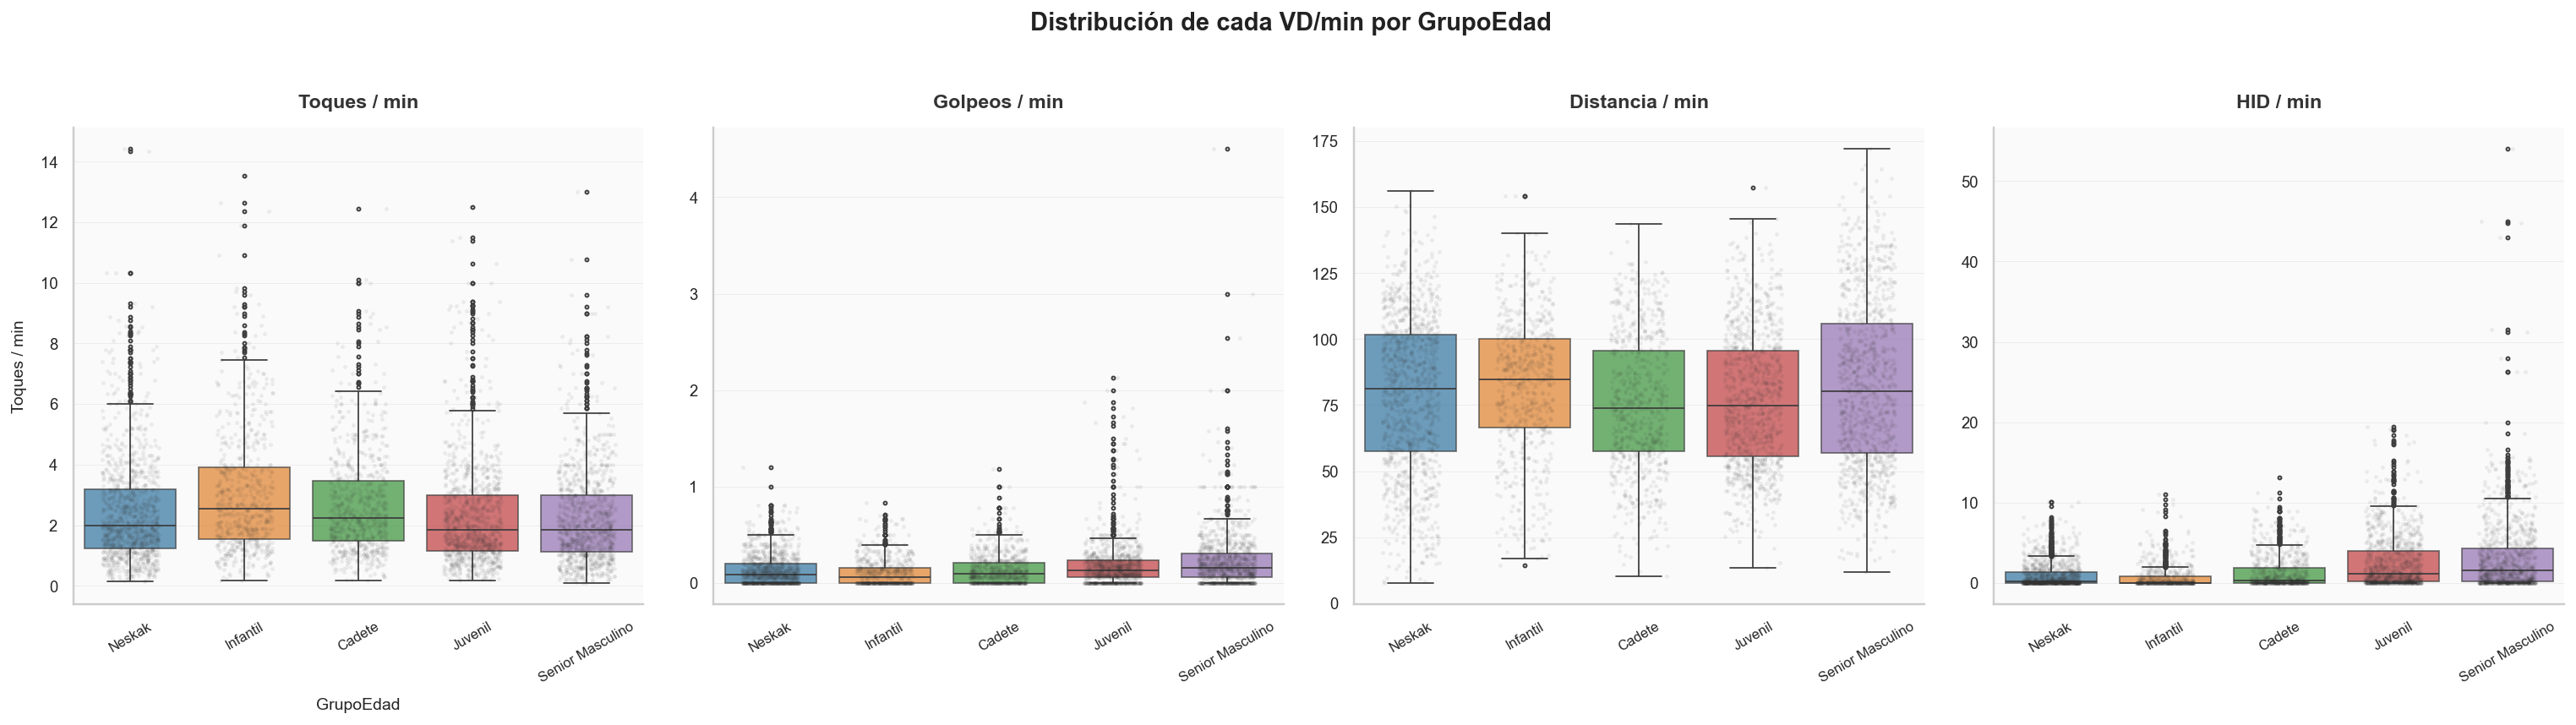

In [4]:
# ── Sección 2: Boxplots por GrupoEdad ─────────────────────

fig, axes = plt.subplots(1, 4, figsize=(22, 6))

for idx, (vd, label) in enumerate(zip(vd_cols, vd_labels)):
    ax = axes[idx]
    
    sns.boxplot(
        data=df, x=ge_col, y=vd, order=ge_orden,
        palette=PAL_GE, ax=ax, fliersize=2, linewidth=0.9,
        boxprops=dict(alpha=0.7),
    )
    sns.stripplot(
        data=df, x=ge_col, y=vd, order=ge_orden,
        color="#333", alpha=0.08, size=2.5, jitter=0.25, ax=ax,
    )
    
    ax.set_title(label, fontsize=12, fontweight="bold", color="#333")
    ax.set_xlabel("" if idx > 0 else "GrupoEdad", fontsize=10)
    ax.set_ylabel(label if idx == 0 else "", fontsize=10)
    ax.tick_params(axis="x", rotation=30, labelsize=8.5)

fig.suptitle(
    "Distribución de cada VD/min por GrupoEdad",
    fontsize=15, fontweight="bold", color="#222", y=1.02,
)
fig.tight_layout()
plt.show()

---
## Sección 3 — ANOVA de un factor (GrupoEdad) + post-hoc Tukey HSD

Para cada VD se realiza:
1. **ANOVA de un factor** (OLS + `anova_lm` Type II) con GrupoEdad como factor.
2. **Tamaño del efecto:** η² (eta-squared) = SS_GrupoEdad / SS_total.
3. **Post-hoc:** Tukey HSD (`statsmodels.stats.multicomp.pairwise_tukeyhsd`), mostrando solo los pares significativos (p < .05).

**Interpretación de η²:** < .01 negligible · .01–.06 pequeño · .06–.14 medio · ≥ .14 grande

In [5]:
# ── Sección 3: ANOVA de un factor + Tukey HSD ─────────────

filas_anova_1way = []

for vd, label in zip(vd_cols, vd_labels):
    display(Markdown(f"### VD: **{label}**"))
    
    # ── ANOVA OLS ─────────────────────────────────────────
    formula = f'Q("{vd}") ~ C({ge_col})'
    modelo = smf.ols(formula, data=df.dropna(subset=[vd, ge_col])).fit()
    tabla_anova = anova_lm(modelo, typ=2)
    
    f_ge = tabla_anova.loc[f"C({ge_col})", "F"]
    p_ge = tabla_anova.loc[f"C({ge_col})", "PR(>F)"]
    ss_ge = tabla_anova.loc[f"C({ge_col})", "sum_sq"]
    ss_resid = tabla_anova.loc["Residual", "sum_sq"]
    eta2 = ss_ge / (ss_ge + ss_resid)
    
    sig = "***" if p_ge < 0.001 else ("**" if p_ge < 0.01 else ("*" if p_ge < 0.05 else "ns"))
    
    filas_anova_1way.append({
        "VD": label,
        "F": round(f_ge, 2),
        "p": p_ge,
        "η²": round(eta2, 4),
        "Tamaño": interpretar_eta2(eta2),
        "Sig.": sig,
    })
    
    print(f"  F({int(tabla_anova.loc[f'C({ge_col})', 'df'])}, "
          f"{int(tabla_anova.loc['Residual', 'df'])}) = {f_ge:.2f}, "
          f"p = {fmt_p(p_ge)}, η² = {eta2:.4f} ({interpretar_eta2(eta2)}) {sig}")
    
    # ── Post-hoc Tukey HSD ────────────────────────────────
    sub_df = df.dropna(subset=[vd, ge_col])
    tukey = pairwise_tukeyhsd(
        endog=sub_df[vd],
        groups=sub_df[ge_col],
        alpha=0.05,
    )
    
    # Extraer pares significativos
    tukey_df = pd.DataFrame(
        data=tukey._results_table.data[1:],
        columns=tukey._results_table.data[0],
    )
    tukey_sig = tukey_df[tukey_df["reject"] == True].copy()
    
    if len(tukey_sig) > 0:
        display(Markdown(f"**Pares significativos (Tukey HSD, p < .05):**"))
        display(tukey_sig[["group1", "group2", "meandiff", "p-adj", "reject"]].reset_index(drop=True))
    else:
        print("  → Ningún par alcanza significación con Tukey HSD (p < .05).")
    print()

# ── Tabla resumen ANOVA 1-way ─────────────────────────────
display(Markdown("### Tabla resumen — ANOVA de un factor (GrupoEdad)"))
df_anova_1way = pd.DataFrame(filas_anova_1way)
df_anova_1way_display = df_anova_1way.copy()
df_anova_1way_display["p"] = df_anova_1way_display["p"].apply(fmt_p)
display(
    df_anova_1way_display.style
    .set_caption("ANOVA 1-way: efecto de GrupoEdad sobre cada VD/min")
    .map(_color_tamano, subset=["Tamaño"])
    .map(_color_sig, subset=["Sig."])
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]},
    ])
)

### VD: **Toques / min**

  F(4, 4441) = 28.36, p = 2.69e-23, η² = 0.0249 (Pequeño) ***


**Pares significativos (Tukey HSD, p < .05):**

,group1,group2,meandiff,p-adj,reject
0,Cadete,Infantil,0.3956,0.0004,True
1,Cadete,Juvenil,-0.3567,0.0003,True
2,Cadete,Neskak,-0.2436,0.0323,True
3,Cadete,Senior Masculino,-0.4670,0.0000,True
4,Infantil,Juvenil,-0.7523,0.0000,True
5,Infantil,Neskak,-0.6392,0.0000,True
6,Infantil,Senior Masculino,-0.8627,0.0000,True
7,Neskak,Senior Masculino,-0.2234,0.0293,True


### VD: **Golpeos / min**

...

  F(4, 4441) = 112.07, p = 3.74e-91, η² = 0.0917 (Medio) ***


**Pares significativos (Tukey HSD, p < .05):**

,group1,group2,meandiff,p-adj,reject
0,Cadete,Infantil,-0.6343,0.0014,True
1,Cadete,Juvenil,1.2312,0.0000,True
2,Cadete,Senior Masculino,1.8497,0.0000,True
3,Infantil,Juvenil,1.8655,0.0000,True
4,Infantil,Senior Masculino,2.4840,0.0000,True
5,Juvenil,Neskak,-1.5963,0.0000,True
6,Juvenil,Senior Masculino,0.6185,0.0001,True
7,Neskak,Senior Masculino,2.2148,0.0000,True


### Tabla resumen — ANOVA de un factor (GrupoEdad)

,VD,F,p,η²,Tamaño,Sig.
0,Toques / min,28.360000,2.69e-23,0.024900,Pequeño,***
1,Golpeos / min,44.420000,1.27e-36,0.038500,Pequeño,***
2,Distancia / min,10.300000,2.65e-08,0.009200,Negligible,***
3,HID / min,112.070000,3.74e-91,0.091700,Medio,***


---
## Sección 4 — Perfiles por GrupoEdad (line plot de medias)

1 figura con 4 subplots. Eje X = GrupoEdad (orden de edad creciente), Eje Y = media de la VD. Línea con marcadores + banda de error (±1 SE).

**Preguntas a responder visualmente:** ¿Los grupos de mayor edad cubren más distancia? ¿Los menores tocan más el balón? ¿El perfil es lineal o presenta algún punto de inflexión?

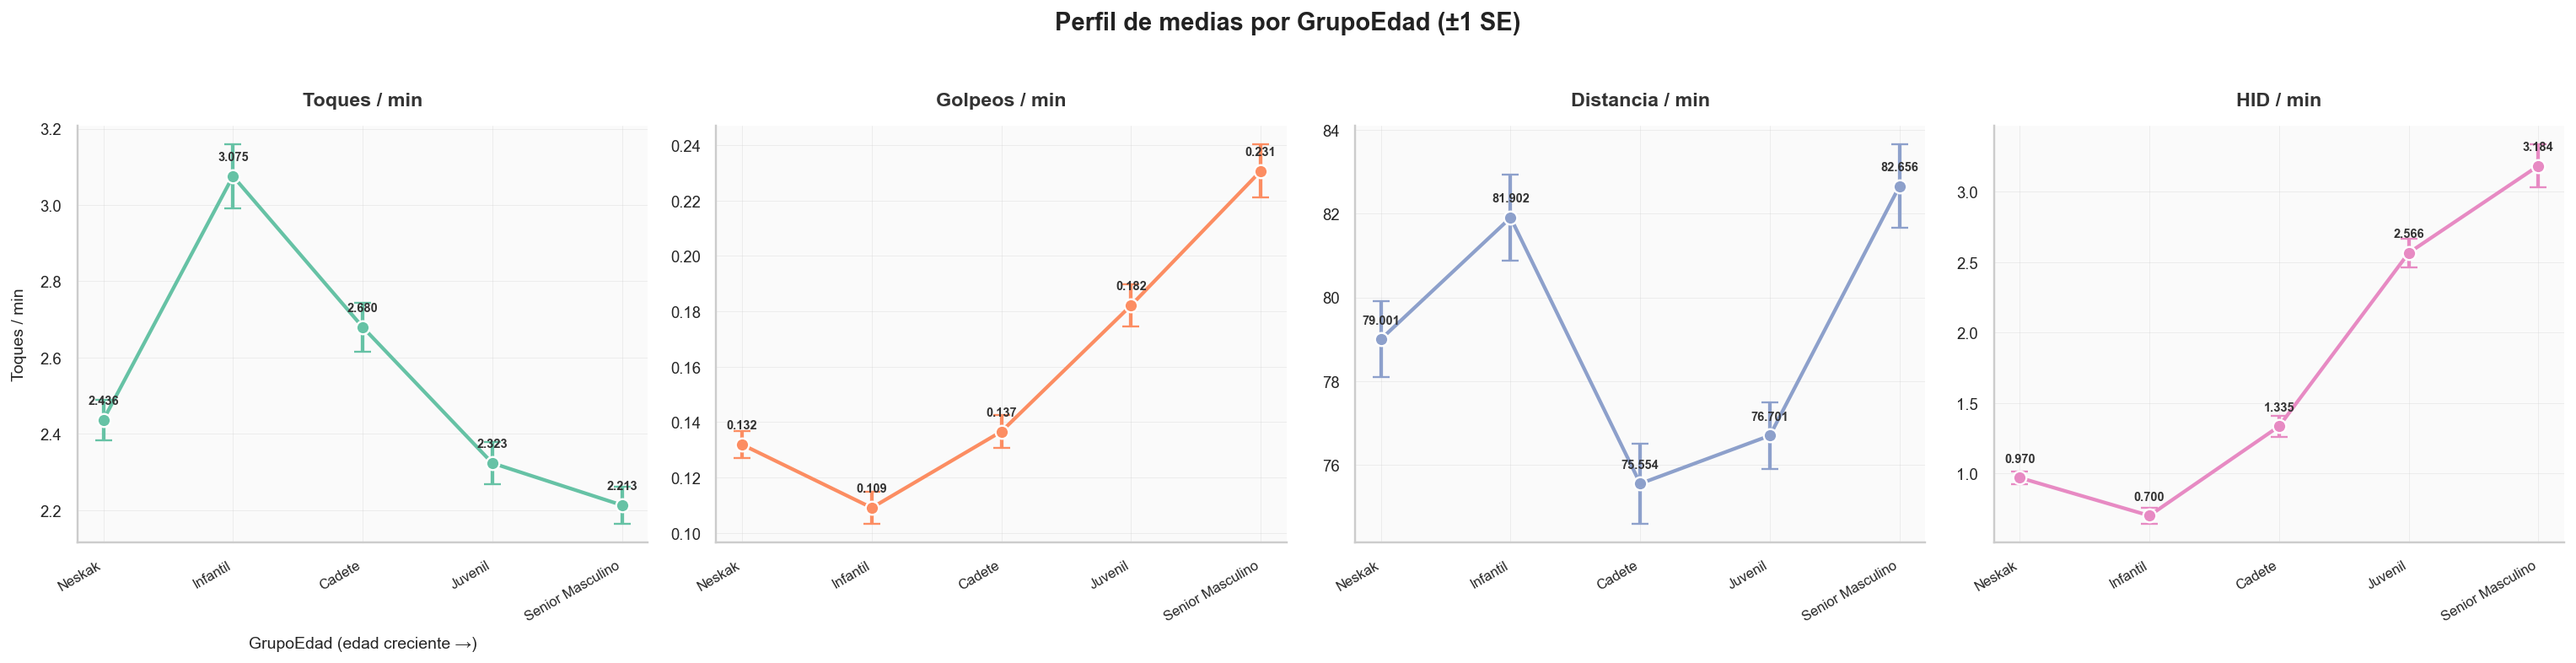

In [6]:
# ── Sección 4: Perfiles por GrupoEdad (line plot) ─────────

fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))

for idx, (vd, label) in enumerate(zip(vd_cols, vd_labels)):
    ax = axes[idx]
    medias = []
    ses = []
    
    for ge in ge_orden:
        x = df.loc[df[ge_col] == ge, vd].dropna()
        medias.append(x.mean())
        ses.append(x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0)
    
    ax.errorbar(
        range(len(ge_orden)), medias, yerr=ses,
        marker="o", markersize=8, capsize=5, capthick=1.3,
        linewidth=2.2, color=colores_vd[idx],
        markeredgecolor="white", markeredgewidth=1.2,
    )
    
    # Anotar valores de media
    for i, (m, s) in enumerate(zip(medias, ses)):
        ax.annotate(
            f"{m:.3f}", xy=(i, m), fontsize=7.5, ha="center", va="bottom",
            xytext=(0, 8), textcoords="offset points", fontweight="bold", color="#333",
        )
    
    ax.set_xticks(range(len(ge_orden)))
    ax.set_xticklabels(ge_orden, fontsize=8.5, rotation=30, ha="right")
    ax.set_xlabel("" if idx > 0 else "GrupoEdad (edad creciente →)", fontsize=10)
    ax.set_ylabel(label if idx == 0 else "", fontsize=10)
    ax.set_title(label, fontsize=12, fontweight="bold", color="#333")

fig.suptitle(
    "Perfil de medias por GrupoEdad (±1 SE)",
    fontsize=15, fontweight="bold", color="#222", y=1.02,
)
fig.tight_layout()
plt.show()

### Interpretación — Perfiles basales por GrupoEdad

Los resultados del Bloque A revelan diferencias basales claras entre GrupoEdad, con magnitudes que varían según la VD:

- **HID/min** presenta la mayor variabilidad entre GrupoEdad (η² = .092, **medio**), con un gradiente creciente claro con la edad: desde 0.70 m/min en Infantil hasta 3.18 m/min en Senior. Los Tukey HSD confirman que prácticamente todos los pares difieren (7 de 10). El % de ceros sigue un gradiente inverso: 52.0 % en Infantil → 18.3 % en Senior. La media condicional (> 0) también crece: 1.46 → 3.90 m/min. La edad opera sobre **ambas partes** (interruptor y modulador).

- **Golpeos/min** también crece con la edad (η² = .039, pequeño): Senior = 0.231 vs Infantil = 0.109. El % de ceros decrece (46.6 % → 22.3 %) y la media condicional aumenta (0.204 → 0.297). De nuevo, ambas partes contribuyen.

- **Toques/min** muestra un pico en **Infantil** (3.076) y luego decrece hasta Senior (2.213). El patrón no es monótono: η² = .025 (pequeño). Los pares más distantes son Infantil vs Senior (Δ = 0.86) y Infantil vs Juvenil (Δ = 0.75).

- **Distancia/min** es la más estable entre GrupoEdad (η² = .009, **negligible**). Las diferencias existen pero son pequeñas y sin un gradiente claro. Cadete y Juvenil cubren menos distancia que Infantil y Senior.

**Implicación para los GLMM:** GrupoEdad debe incluirse como **efecto fijo** en todos los modelos. Para HID/min la diferencia basal entre GrupoEdad (η² = .092) es mayor que muchos efectos de las VI de tarea, por lo que ignorarla sesgaría gravemente las estimaciones.

---
# BLOQUE B — Interacción VI_tarea × GrupoEdad: moderación

Se analizan las **16 combinaciones** (4 VI × 4 VD) para determinar si el efecto base de cada VI de tarea (documentado en la Fase 3) se mantiene estable a través de los 5 GrupoEdad o si la edad modera dicho efecto.

**Criterio visual:** Si en los interaction plots las líneas de los distintos GrupoEdad son **paralelas** → el efecto base no cambia con la edad. Si **divergen o se cruzan** → la edad modera el efecto.

---
## Sección 5 — Interaction plots (VI_tarea × GrupoEdad)

Para cada VI de tarea: 1 figura con 4 paneles (uno por VD).
- **Eje X:** niveles de la VI de tarea (2 niveles).
- **Líneas separadas** por GrupoEdad (5 líneas, una por grupo, con colores distintos).
- **Eje Y:** media ± SE.

**Layout:** 4 figuras (una por VI) × 4 paneles = **16 interaction plots** en total.

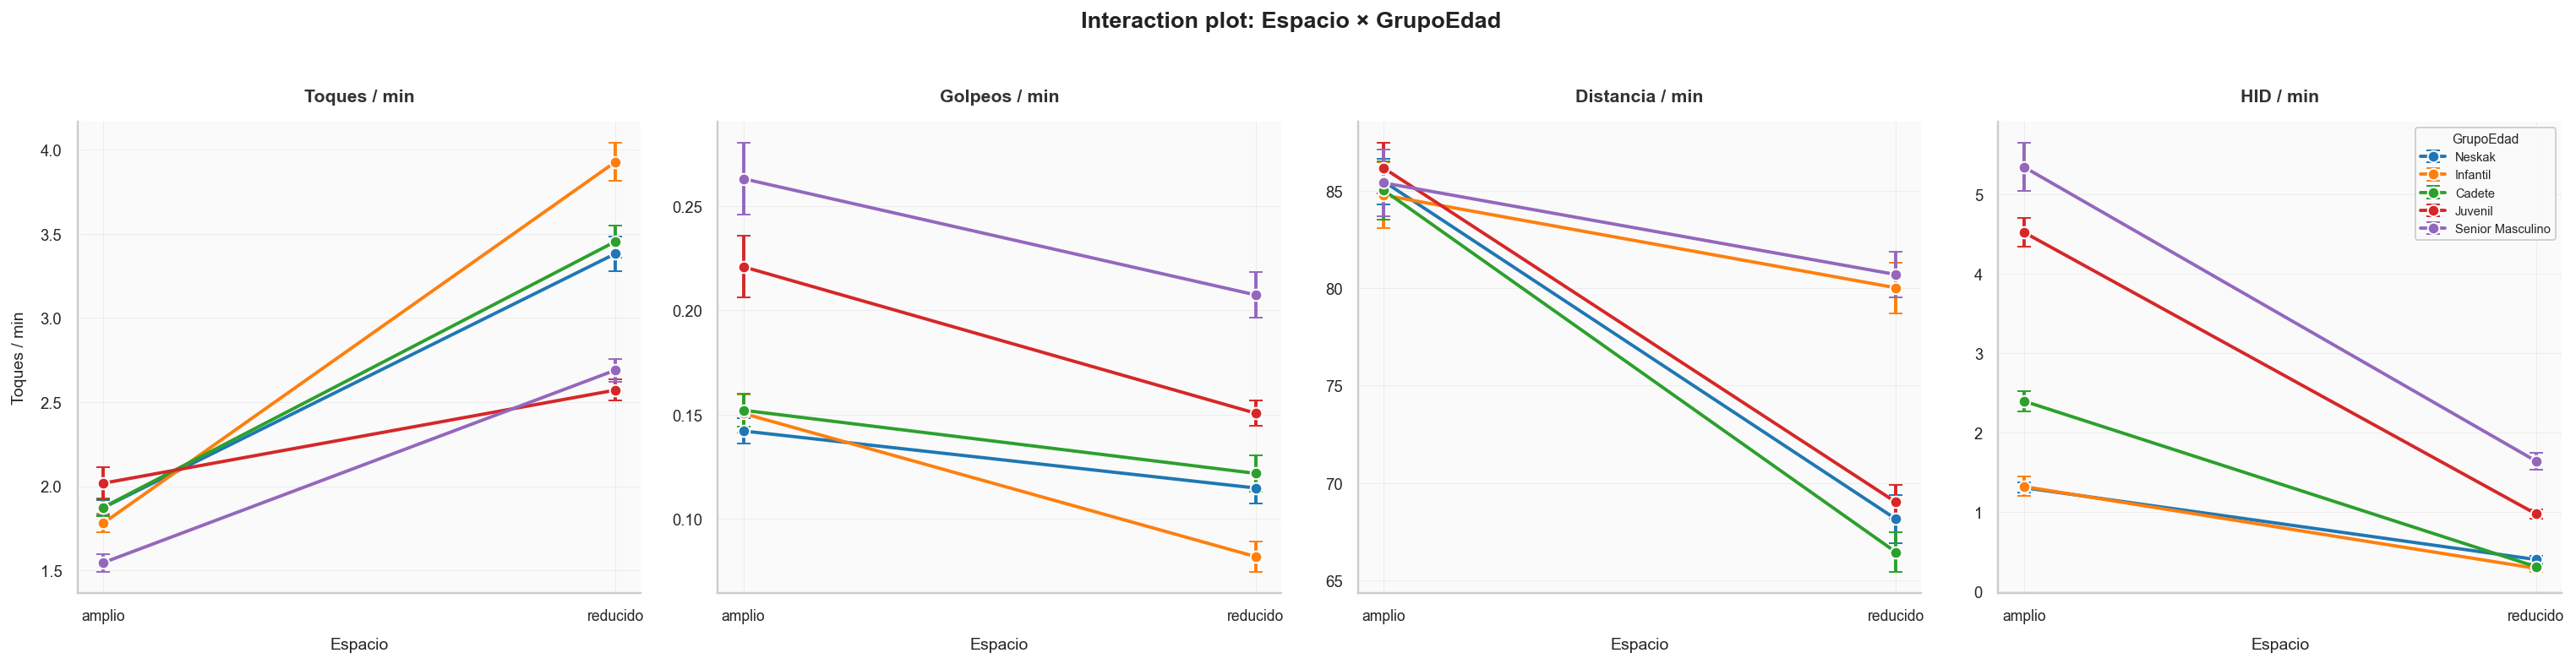

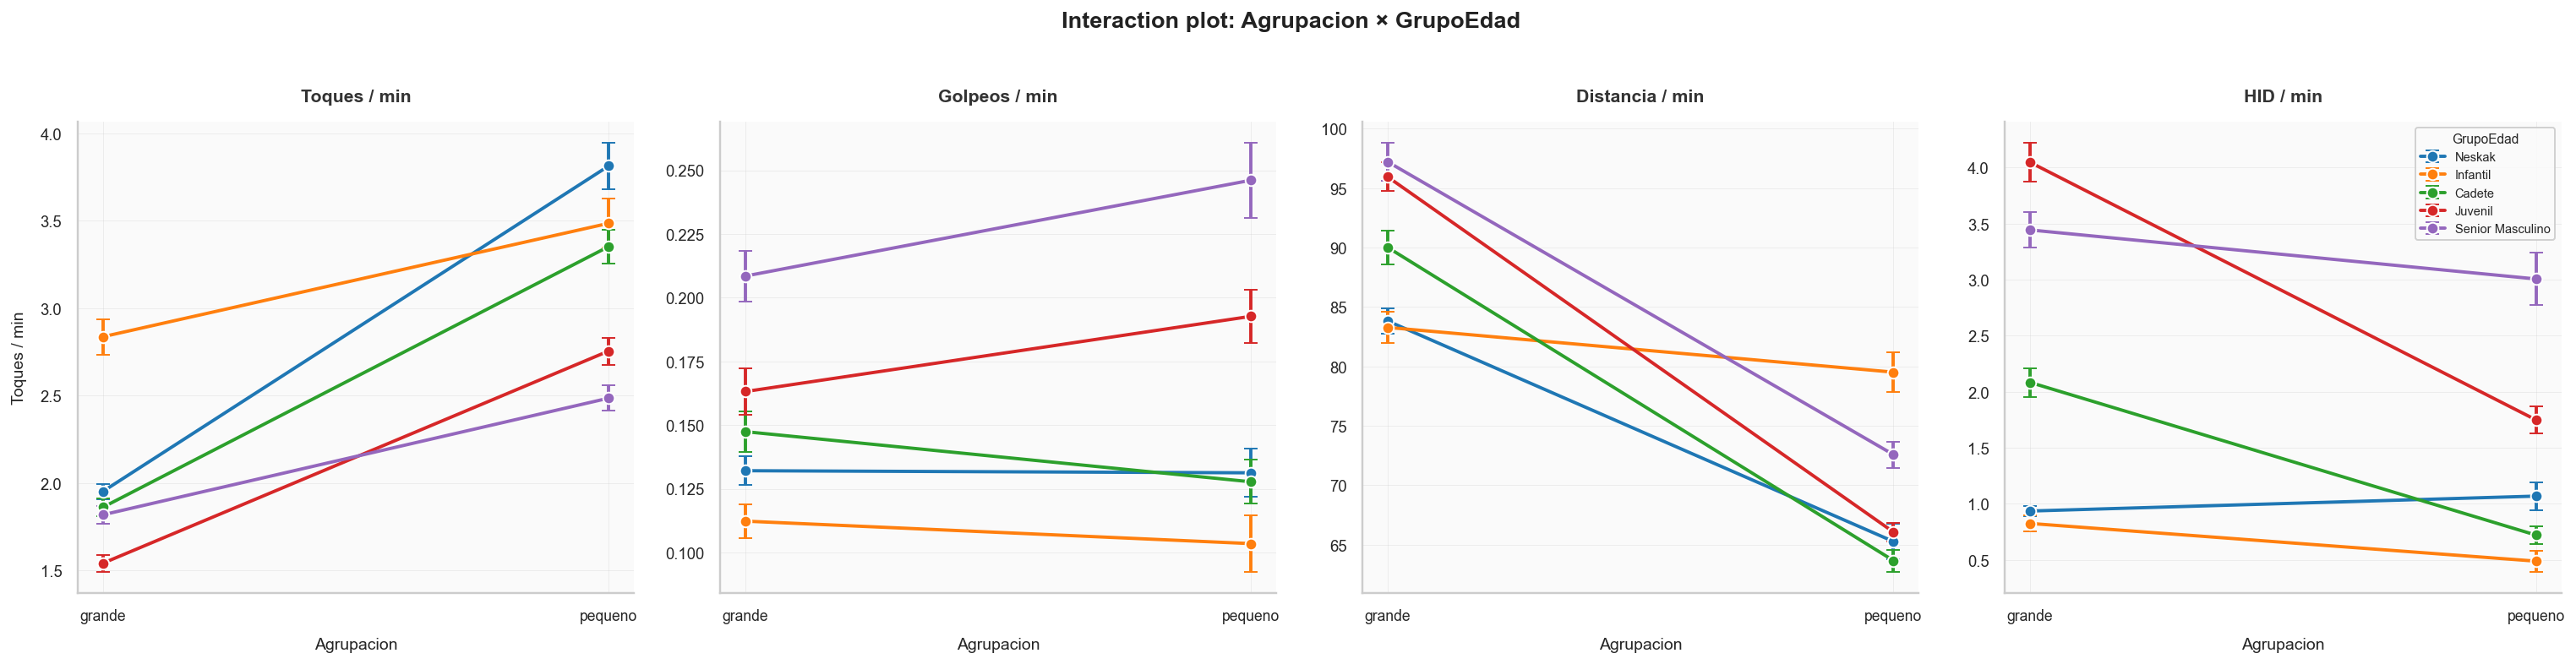

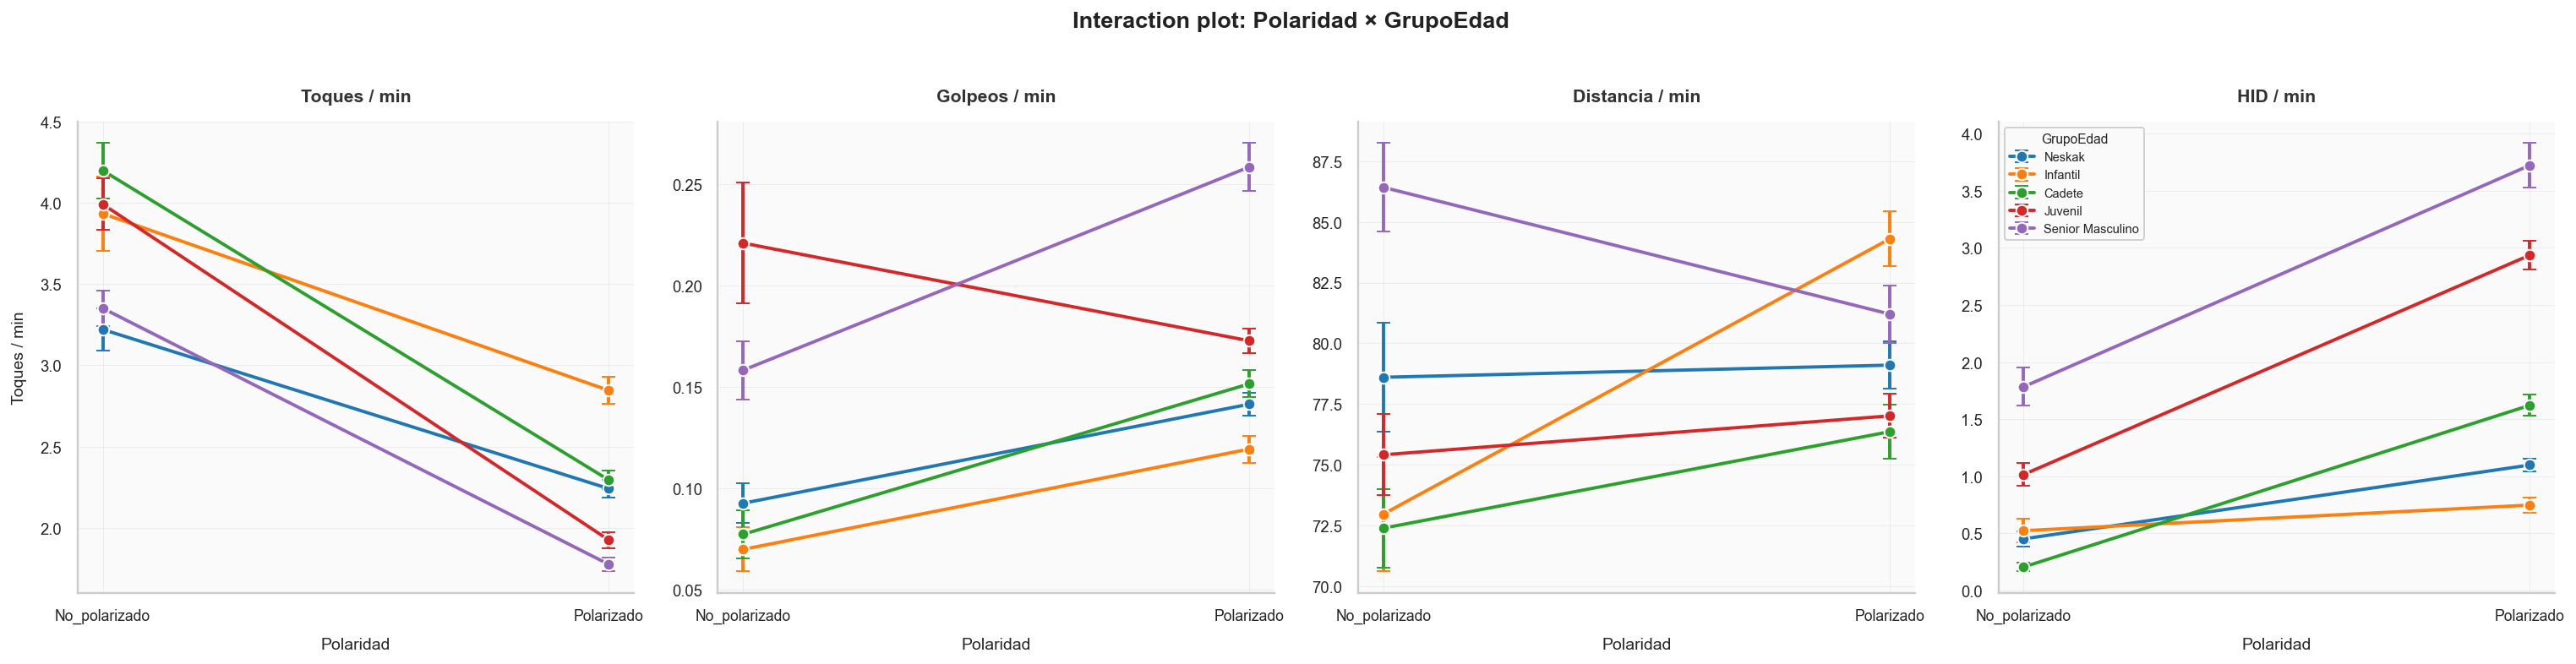

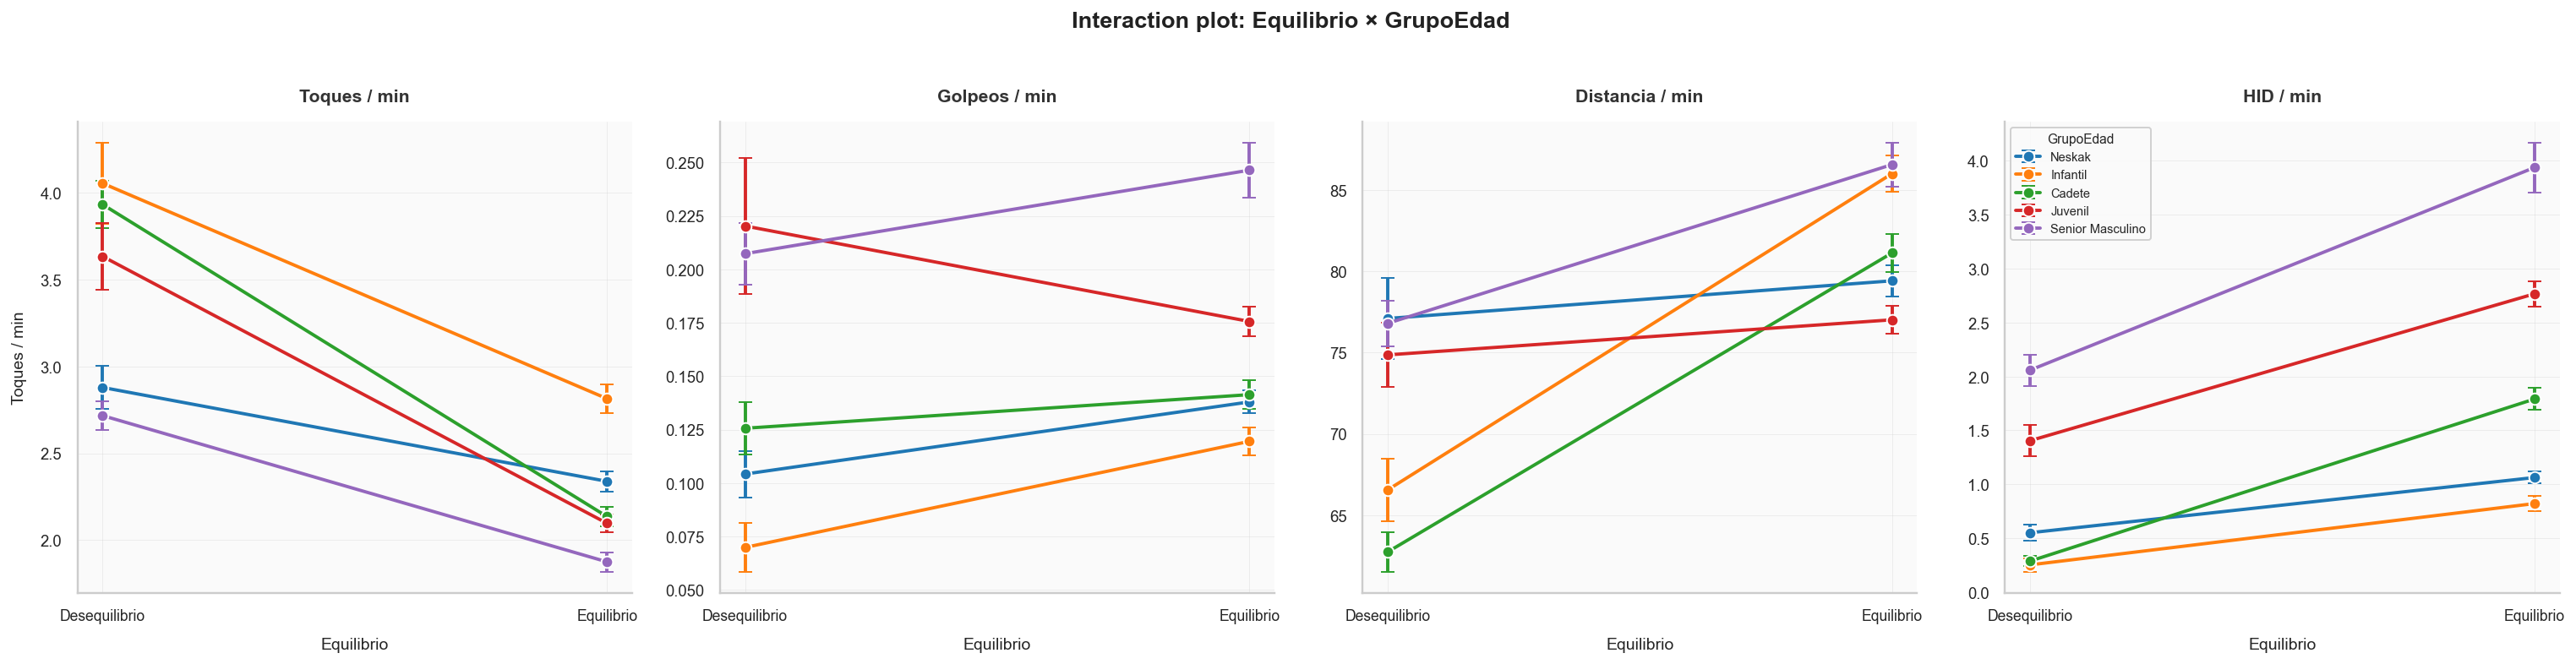

In [7]:
# ── Sección 5: Interaction plots VI × GrupoEdad ───────────

for vi in vi_cols:
    niveles_vi = vi_niveles[vi]
    
    fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))
    
    for idx, (vd, label) in enumerate(zip(vd_cols, vd_labels)):
        ax = axes[idx]
        
        for k, ge in enumerate(ge_orden):
            medias = []
            ses = []
            for niv in niveles_vi:
                sub = df[(df[vi] == niv) & (df[ge_col] == ge)][vd].dropna()
                medias.append(sub.mean() if len(sub) > 0 else np.nan)
                se = sub.std(ddof=1) / np.sqrt(len(sub)) if len(sub) > 1 else 0
                ses.append(se)
            
            ax.errorbar(
                range(len(niveles_vi)), medias, yerr=ses,
                marker="o", markersize=7, capsize=4, capthick=1.2,
                linewidth=2.0, color=PAL_GE[k], label=ge,
                markeredgecolor="white", markeredgewidth=1.0,
            )
        
        ax.set_xticks(range(len(niveles_vi)))
        ax.set_xticklabels(niveles_vi, fontsize=9)
        ax.set_xlabel(vi, fontsize=10)
        ax.set_ylabel(label if idx == 0 else "", fontsize=10)
        ax.set_title(label, fontsize=11, fontweight="bold", color="#333")
        if idx == 3:  # leyenda solo en el último panel
            ax.legend(fontsize=7.5, loc="best", framealpha=0.9, title="GrupoEdad", title_fontsize=8)
    
    fig.suptitle(
        f"Interaction plot: {vi} × GrupoEdad",
        fontsize=14, fontweight="bold", color="#222", y=1.02,
    )
    fig.tight_layout()
    plt.show()

---
## Sección 6 — ANOVA 2-way (VI_tarea × GrupoEdad)

Para cada combinación VI × VD (16 en total):
1. **ANOVA factorial 2-way** con OLS: `VD ~ C(VI) * C(GrupoEdad)` → `anova_lm(modelo, typ=2)`.
2. Extraer: F y p del efecto principal de VI, efecto principal de GrupoEdad, e interacción VI × GrupoEdad.
3. Calcular **η² parcial** para cada término.

**Tabla resumen global** (16 filas): VI, VD, F_VI, p_VI, F_GE, p_GE, F_interacción, p_interacción, η²p_interacción.

Se marcan con asterisco las interacciones significativas (p < .05).

In [8]:
# ── Sección 6: ANOVA 2-way VI × GrupoEdad ────────────────

filas_anova_2way = []

for vi in vi_cols:
    for vd, label in zip(vd_cols, vd_labels):
        # ── ANOVA factorial 2-way ─────────────────────────
        formula = f'Q("{vd}") ~ C({vi}) * C({ge_col})'
        sub_df = df.dropna(subset=[vd, vi, ge_col])
        modelo = smf.ols(formula, data=sub_df).fit()
        tabla_anova = anova_lm(modelo, typ=2)
        
        # Claves en la tabla ANOVA
        key_vi = f"C({vi})"
        key_ge = f"C({ge_col})"
        key_inter = f"C({vi}):C({ge_col})"
        
        # Efecto principal VI
        f_vi = tabla_anova.loc[key_vi, "F"]
        p_vi = tabla_anova.loc[key_vi, "PR(>F)"]
        ss_vi = tabla_anova.loc[key_vi, "sum_sq"]
        
        # Efecto principal GrupoEdad
        f_ge = tabla_anova.loc[key_ge, "F"]
        p_ge = tabla_anova.loc[key_ge, "PR(>F)"]
        ss_ge = tabla_anova.loc[key_ge, "sum_sq"]
        
        # Interacción VI × GrupoEdad
        f_inter = tabla_anova.loc[key_inter, "F"]
        p_inter = tabla_anova.loc[key_inter, "PR(>F)"]
        ss_inter = tabla_anova.loc[key_inter, "sum_sq"]
        ss_resid = tabla_anova.loc["Residual", "sum_sq"]
        
        # η²p = SS_efecto / (SS_efecto + SS_residual)
        eta2p_vi = ss_vi / (ss_vi + ss_resid)
        eta2p_ge = ss_ge / (ss_ge + ss_resid)
        eta2p_inter = ss_inter / (ss_inter + ss_resid)
        
        sig = "***" if p_inter < 0.001 else ("**" if p_inter < 0.01 else ("*" if p_inter < 0.05 else "ns"))
        
        filas_anova_2way.append({
            "VI": vi,
            "VD": label,
            "F_VI": round(f_vi, 2),
            "p_VI": p_vi,
            "η²p_VI": round(eta2p_vi, 4),
            "F_GE": round(f_ge, 2),
            "p_GE": p_ge,
            "η²p_GE": round(eta2p_ge, 4),
            "F_interacción": round(f_inter, 2),
            "p_interacción": p_inter,
            "η²p_interacción": round(eta2p_inter, 4),
            "Tamaño_inter": interpretar_eta2(eta2p_inter),
            "Sig.": sig,
        })

df_anova_2way = pd.DataFrame(filas_anova_2way)

# ── Tabla de display ──────────────────────────────────────
df_a2_display = df_anova_2way.copy()
df_a2_display["p_VI"] = df_a2_display["p_VI"].apply(fmt_p)
df_a2_display["p_GE"] = df_a2_display["p_GE"].apply(fmt_p)
df_a2_display["p_interacción"] = df_a2_display["p_interacción"].apply(fmt_p)

display(Markdown("### Tabla resumen — ANOVA 2-way: VI_tarea × GrupoEdad"))
display(
    df_a2_display.style
    .set_caption("ANOVA Type II: efectos principales e interacción VI × GrupoEdad (16 combinaciones)")
    .map(_color_tamano, subset=["Tamaño_inter"])
    .map(_color_sig, subset=["Sig."])
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]},
    ])
)

# ── Resumen numérico ──────────────────────────────────────
n_sig = (df_anova_2way["p_interacción"] < 0.05).sum()
n_total = len(df_anova_2way)
print(f"\n✔ Interacciones significativas (p < .05): {n_sig} de {n_total} ({n_sig/n_total*100:.1f}%)")

if n_sig > 0:
    print("\nDetalle de interacciones significativas:")
    for _, row in df_anova_2way[df_anova_2way["p_interacción"] < 0.05].iterrows():
        print(f"  • {row['VI']} × GrupoEdad → {row['VD']}: "
              f"F = {row['F_interacción']:.2f}, p = {fmt_p(row['p_interacción'])}, "
              f"η²p = {row['η²p_interacción']:.4f} ({row['Tamaño_inter']})")

### Tabla resumen — ANOVA 2-way: VI_tarea × GrupoEdad

,VI,VD,F_VI,p_VI,η²p_VI,F_GE,p_GE,η²p_GE,F_interacción,p_interacción,η²p_interacción,Tamaño_inter,Sig.
0,Espacio,Toques / min,705.280000,2.40e-144,0.137200,35.160000,6.00e-29,0.030700,26.600000,7.74e-22,0.023400,Pequeño,***
1,Espacio,Golpeos / min,57.910000,3.34e-14,0.012900,49.000000,2.13e-40,0.042300,1.950000,0.1001,0.001800,Negligible,ns
2,Espacio,Distancia / min,240.610000,6.94e-53,0.051400,15.580000,1.16e-12,0.013900,14.080000,2.03e-11,0.012500,Pequeño,***
3,Espacio,HID / min,793.640000,8.79e-161,0.151800,171.080000,1.91e-136,0.133600,52.830000,1.53e-43,0.045500,Pequeño,***
4,Agrupacion,Toques / min,518.330000,1.31e-108,0.104600,59.020000,1.29e-48,0.050500,20.250000,1.52e-16,0.017900,Pequeño,***
5,Agrupacion,Golpeos / min,2.590000,0.1075,0.000600,40.330000,3.08e-33,0.035100,2.680000,0.0298,0.002400,Negligible,*
6,Agrupacion,Distancia / min,723.390000,9.76e-148,0.140200,23.860000,1.49e-19,0.021100,26.360000,1.24e-21,0.023200,Pequeño,***
7,Agrupacion,HID / min,89.590000,4.62e-21,0.019800,135.520000,2.14e-109,0.108900,22.570000,1.79e-18,0.019900,Pequeño,***
8,Polaridad,Toques / min,658.500000,1.58e-135,0.129300,38.470000,1.08e-31,0.033500,12.660000,3.03e-10,0.011300,Pequeño,***
9,Polaridad,Golpeos / min,35.100000,3.37e-09,0.007900,47.450000,4.06e-39,0.041000,11.200000,4.82e-09,0.010000,Pequeño,***



✔ Interacciones significativas (p < .05): 15 de 16 (93.8%)

Detalle de interacciones significativas:
  • Espacio × GrupoEdad → Toques / min: F = 26.60, p = 7.74e-22, η²p = 0.0234 (Pequeño)
  • Espacio × GrupoEdad → Distancia / min: F = 14.08, p = 2.03e-11, η²p = 0.0125 (Pequeño)
  • Espacio × GrupoEdad → HID / min: F = 52.83, p = 1.53e-43, η²p = 0.0455 (Pequeño)
  • Agrupacion × GrupoEdad → Toques / min: F = 20.25, p = 1.52e-16, η²p = 0.0179 (Pequeño)
  • Agrupacion × GrupoEdad → Golpeos / min: F = 2.68, p = 0.0298, η²p = 0.0024 (Negligible)
  • Agrupacion × GrupoEdad → Distancia / min: F = 26.36, p = 1.24e-21, η²p = 0.0232 (Pequeño)
  • Agrupacion × GrupoEdad → HID / min: F = 22.57, p = 1.79e-18, η²p = 0.0199 (Pequeño)
  • Polaridad × GrupoEdad → Toques / min: F = 12.66, p = 3.03e-10, η²p = 0.0113 (Pequeño)
  • Polaridad × GrupoEdad → Golpeos / min: F = 11.20, p = 4.82e-09, η²p = 0.0100 (Pequeño)
  • Polaridad × GrupoEdad → Distancia / min: F = 6.38, p = 4.04e-05, η²p = 0.0057 (Negli

---
## Sección 6b — Heatmaps resumen de interacciones VI × GrupoEdad

Dos heatmaps lado a lado (mismo formato que el NB04, Sección 4):
1. **η²p de la interacción VI × GrupoEdad** — Filas = 4 VI, Columnas = 4 VD.
2. **−log₁₀(p) de la interacción** — Líneas de referencia en 1.3 (p = .05) y 3.0 (p = .001).

Esto permite comparar visualmente la magnitud de la moderación por edad con las interacciones entre VI de tarea de la Fase 4.

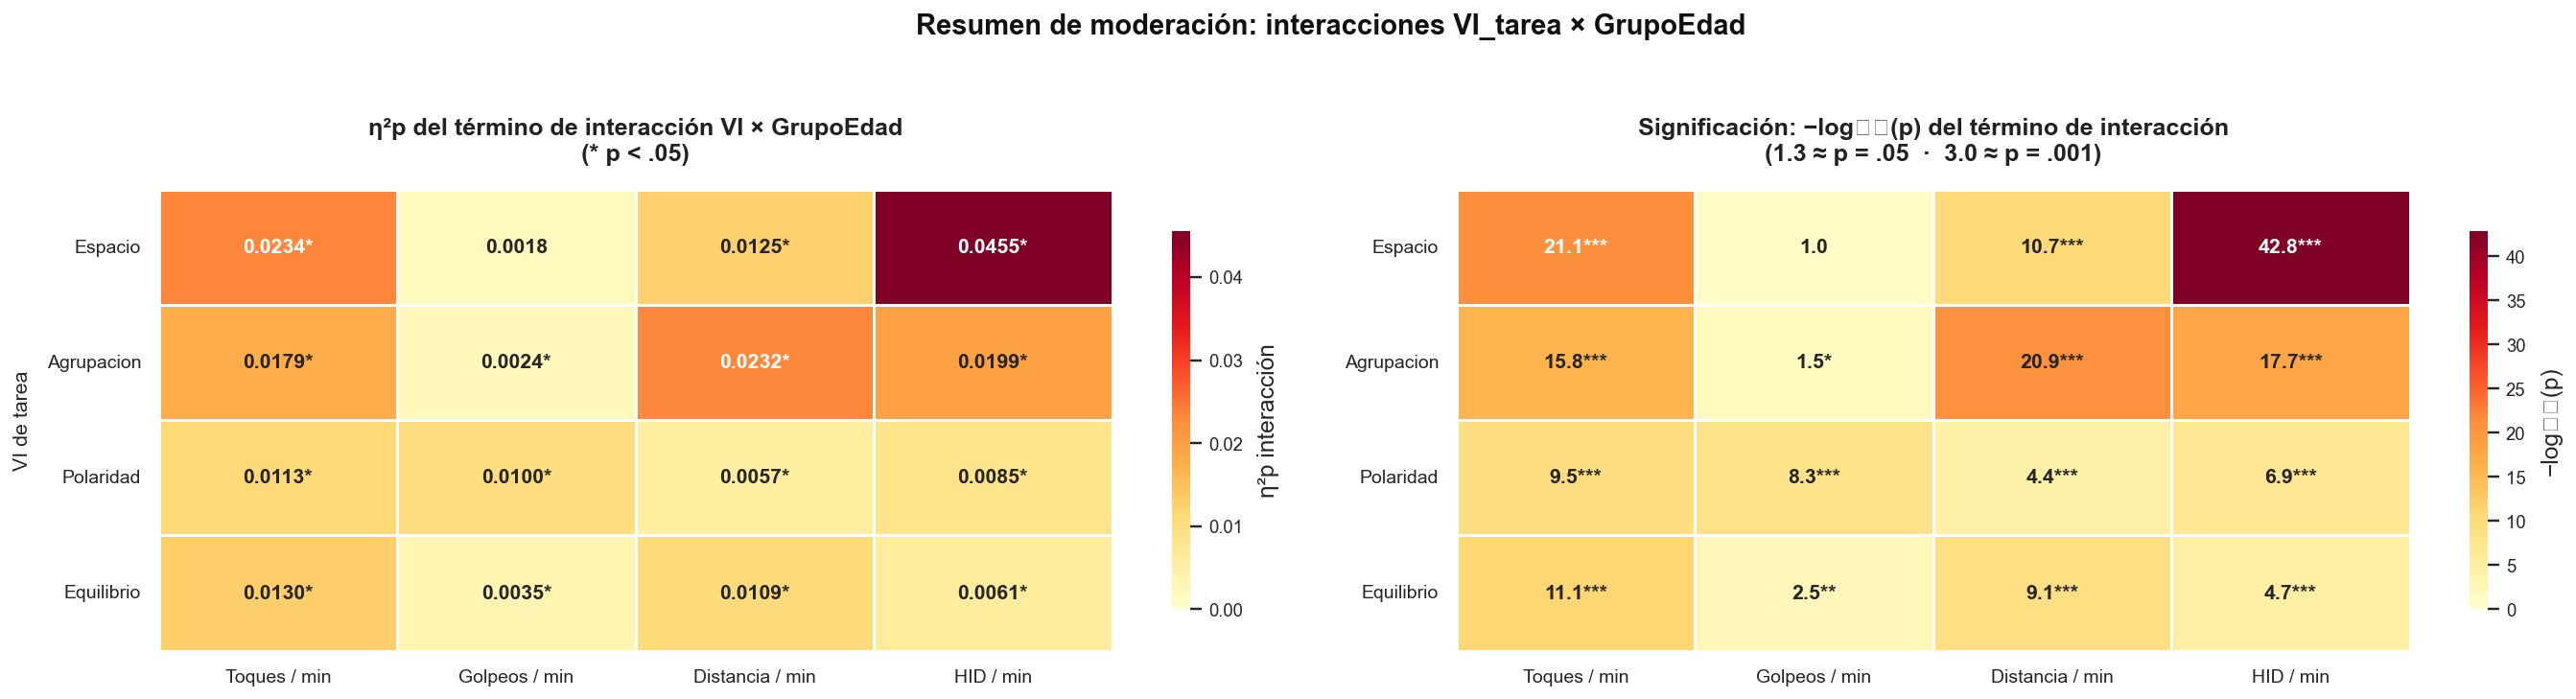

✔ Interacciones VI × GE significativas (p < .05): 15 de 16
✔ Interacciones VI × GE con η²p ≥ .01 (relevantes): 10 de 16

Comparación con Fase 4 (VI × VI): 5 de 24 con η²p ≥ .01.
→ La moderación por GrupoEdad (10/16 = 62%) es más pervasiva que
  las interacciones entre VI de tarea (5/24 = 21%).


In [9]:
# ── Sección 6b: Heatmaps resumen VI × GrupoEdad ──────────

# ── 6b.1 Preparar pivots ─────────────────────────────────
pivot_eta_ge = df_anova_2way.pivot_table(
    index="VI", columns="VD", values="η²p_interacción", aggfunc="first"
)[vd_labels]

pivot_p_ge = df_anova_2way.pivot_table(
    index="VI", columns="VD", values="p_interacción", aggfunc="first"
)[vd_labels]

pivot_logp_ge = -np.log10(pivot_p_ge.clip(lower=1e-300))

# Reordenar filas por VI
pivot_eta_ge = pivot_eta_ge.reindex(vi_cols)
pivot_p_ge = pivot_p_ge.reindex(vi_cols)
pivot_logp_ge = pivot_logp_ge.reindex(vi_cols)

# ── 6b.2 Anotaciones con asteriscos ──────────────────────
annot_eta_ge = pd.DataFrame("", index=pivot_eta_ge.index, columns=pivot_eta_ge.columns)
for vi in pivot_eta_ge.index:
    for vd_l in pivot_eta_ge.columns:
        eta_val = pivot_eta_ge.loc[vi, vd_l]
        p_val = pivot_p_ge.loc[vi, vd_l]
        star = "*" if p_val < 0.05 else ""
        annot_eta_ge.loc[vi, vd_l] = f"{eta_val:.4f}{star}"

annot_logp_ge = pd.DataFrame("", index=pivot_logp_ge.index, columns=pivot_logp_ge.columns)
for vi in pivot_logp_ge.index:
    for vd_l in pivot_logp_ge.columns:
        logp_val = pivot_logp_ge.loc[vi, vd_l]
        p_val = pivot_p_ge.loc[vi, vd_l]
        star = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else ""))
        annot_logp_ge.loc[vi, vd_l] = f"{logp_val:.1f}{star}"

# ── 6b.3 Dibujar heatmaps lado a lado ────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))

# Heatmap 1: η²p
sns.heatmap(
    pivot_eta_ge.astype(float), annot=annot_eta_ge, fmt="", cmap="YlOrRd",
    linewidths=1.5, linecolor="white", ax=ax1, vmin=0,
    cbar_kws={"label": "η²p interacción", "shrink": 0.82},
    annot_kws={"fontsize": 11, "fontweight": "bold"},
)
ax1.set_title(
    "η²p del término de interacción VI × GrupoEdad\n(* p < .05)",
    fontsize=13, fontweight="bold", color="#222", pad=16,
)
ax1.set_ylabel("VI de tarea", fontsize=11)
ax1.set_xlabel("")
ax1.tick_params(labelsize=10)
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)

# Heatmap 2: -log10(p)
sns.heatmap(
    pivot_logp_ge.astype(float), annot=annot_logp_ge, fmt="", cmap="YlOrRd",
    linewidths=1.5, linecolor="white", ax=ax2, vmin=0,
    cbar_kws={"label": "−log₁₀(p)", "shrink": 0.82},
    annot_kws={"fontsize": 11, "fontweight": "bold"},
)
ax2.set_title(
    "Significación: −log₁₀(p) del término de interacción\n"
    "(1.3 ≈ p = .05  ·  3.0 ≈ p = .001)",
    fontsize=13, fontweight="bold", color="#222", pad=16,
)
ax2.set_ylabel("")
ax2.set_xlabel("")
ax2.tick_params(labelsize=10)
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)

fig.suptitle(
    "Resumen de moderación: interacciones VI_tarea × GrupoEdad",
    fontsize=15, fontweight="bold", color="#111", y=1.04,
)
fig.tight_layout()
plt.show()

# ── 6b.4 Conteo resumen ──────────────────────────────────
n_sig = (df_anova_2way["p_interacción"] < 0.05).sum()
n_rel = (df_anova_2way["η²p_interacción"] >= 0.01).sum()
print(f"✔ Interacciones VI × GE significativas (p < .05): {n_sig} de 16")
print(f"✔ Interacciones VI × GE con η²p ≥ .01 (relevantes): {n_rel} de 16")
print(f"\nComparación con Fase 4 (VI × VI): 5 de 24 con η²p ≥ .01.")
print(f"→ La moderación por GrupoEdad ({n_rel}/16 = {n_rel/16*100:.0f}%) es más pervasiva que")
print(f"  las interacciones entre VI de tarea (5/24 = 21%).")

### Interpretación — ANOVA 2-way y heatmaps de moderación

**Panorama general:** 15 de 16 interacciones VI × GrupoEdad son significativas (p < .05), y **9 de 16** tienen η²p ≥ .01 (tamaño al menos pequeño). Esto contrasta con la Fase 4, donde solo 5 de 24 interacciones entre VI de tarea superaban el umbral. **La moderación por GrupoEdad es más pervasiva que las interacciones entre VI de tarea.**

**Por VD (columnas del heatmap):**
- **Toques/min:** 4 de 4 VI muestran interacción con GrupoEdad (η²p ≥ .01). Es la VD más moderada por la edad. En la Fase 4, era la más aditiva entre VI de tarea — aquí sucede lo contrario.
- **Distancia/min:** 3 de 4 (todas excepto Polaridad). Moderación generalizada.
- **HID/min:** 2 de 4 (Espacio y Agrupación). El η²p de Espacio × GE sobre HID (.046) es el **mayor del dataset**, casi alcanzando tamaño medio.
- **Golpeos/min:** solo 1 de 4 (Polaridad, η²p = .010). La menos moderada.

**Por VI (filas del heatmap):**
- **Espacio:** moderación fuerte sobre Toques (.023), Distancia (.013) y HID (.046). El efecto de Espacio no es estable a través de los GrupoEdad.
- **Agrupación:** moderación generalizada (3 de 4 VD con η²p ≥ .01). Destaca Agrup → Distancia (.023) y Agrup → HID (.020).
- **Polaridad:** moderación sobre Toques (.011) y Golpeos (.010), pero no sobre Distancia ni HID.
- **Equilibrio:** moderación sobre Toques (.013) y Distancia (.011), pero no sobre Golpeos ni HID.

**Implicación:** Los GLMM de Toques/min necesitarán los 4 términos de interacción VI × GE. Los de HID/min necesitarán al menos Espacio × GE y Agrupación × GE. Para Golpeos/min, solo Polaridad × GE se justifica empíricamente.

---
## Sección 7 — Tabla de Δ por GrupoEdad y heatmap de Cohen's d

Para cada VI de tarea × cada VD, dentro de cada GrupoEdad se calcula:
- **Δ** = media(nivel_1) − media(nivel_2) de la VD (el mismo Δ de la Fase 3, pero estratificado por GrupoEdad).
- **Cohen's d** como medida estandarizada del efecto.

Esto permite visualizar si la magnitud del efecto varía entre grupos de edad.

In [10]:
# ── Sección 7.1: Tabla de Δ por GrupoEdad ────────────────

filas_delta = []

for vi in vi_cols:
    niveles = vi_niveles[vi]
    niv1, niv2 = niveles[0], niveles[1]
    
    for vd, label in zip(vd_cols, vd_labels):
        for ge in ge_orden:
            g1 = df[(df[vi] == niv1) & (df[ge_col] == ge)][vd].dropna()
            g2 = df[(df[vi] == niv2) & (df[ge_col] == ge)][vd].dropna()
            
            m1 = g1.mean() if len(g1) > 0 else np.nan
            m2 = g2.mean() if len(g2) > 0 else np.nan
            delta = m1 - m2 if not (np.isnan(m1) or np.isnan(m2)) else np.nan
            
            # Cohen's d
            d = cohen_d(g1, g2) if len(g1) > 1 and len(g2) > 1 else np.nan
            
            # IC 95% del Δ (diferencia de medias independientes)
            if len(g1) > 1 and len(g2) > 1:
                se_diff = np.sqrt(g1.var(ddof=1)/len(g1) + g2.var(ddof=1)/len(g2))
                ic_lo = delta - 1.96 * se_diff
                ic_hi = delta + 1.96 * se_diff
            else:
                ic_lo, ic_hi = np.nan, np.nan
            
            filas_delta.append({
                "VI": vi,
                "VD": label,
                "GrupoEdad": ge,
                f"Media ({niv1})": round(m1, 4) if not np.isnan(m1) else np.nan,
                f"Media ({niv2})": round(m2, 4) if not np.isnan(m2) else np.nan,
                "Δ": round(delta, 4) if not np.isnan(delta) else np.nan,
                "IC95% inf": round(ic_lo, 4) if not np.isnan(ic_lo) else np.nan,
                "IC95% sup": round(ic_hi, 4) if not np.isnan(ic_hi) else np.nan,
                "Cohen d": round(d, 4) if not np.isnan(d) else np.nan,
            })

df_delta = pd.DataFrame(filas_delta)

# Mostrar tabla por VI
for vi in vi_cols:
    display(Markdown(f"### VI: **{vi}** — Δ por GrupoEdad"))
    sub = df_delta[df_delta["VI"] == vi].reset_index(drop=True)
    display(sub.style.format(precision=4).set_caption(f"Δ estratificado por GrupoEdad: {vi}"))
    print()

### VI: **Espacio** — Δ por GrupoEdad

,VI,VD,GrupoEdad,Media (amplio),Media (reducido),Δ,IC95% inf,IC95% sup,Cohen d,Media (grande),Media (pequeno),Media (No_polarizado),Media (Polarizado),Media (Desequilibrio),Media (Equilibrio)
0,Espacio,Toques / min,Neskak,1.8720,3.3822,-1.5102,-1.7333,-1.2870,-0.9503,nan,nan,nan,nan,nan,nan
1,Espacio,Toques / min,Infantil,1.7800,3.9276,-2.1476,-2.3950,-1.9002,-1.1942,nan,nan,nan,nan,nan,nan
2,Espacio,Toques / min,Cadete,1.8744,3.4544,-1.5800,-1.7990,-1.3609,-1.0457,nan,nan,nan,nan,nan,nan
3,Espacio,Toques / min,Juvenil,2.0177,2.5714,-0.5537,-0.7777,-0.3297,-0.3176,nan,nan,nan,nan,nan,nan
4,Espacio,Toques / min,Senior Masculino,1.5453,2.6897,-1.1444,-1.3135,-0.9753,-0.7897,nan,nan,nan,nan,nan,nan
5,Espacio,Golpeos / min,Neskak,0.1421,0.1147,0.0274,0.0084,0.0464,0.1739,nan,nan,nan,nan,nan,nan
6,Espacio,Golpeos / min,Infantil,0.1505,0.0818,0.0688,0.0461,0.0914,0.4888,nan,nan,nan,nan,nan,nan
7,Espacio,Golpeos / min,Cadete,0.1521,0.1217,0.0303,0.0072,0.0534,0.1918,nan,nan,nan,nan,nan,nan
8,Espacio,Golpeos / min,Juvenil,0.2210,0.1506,0.0703,0.0390,0.1016,0.2988,nan,nan,nan,nan,nan,nan
9,Espacio,Golpeos / min,Senior Masculino,0.2633,0.2075,0.0558,0.0159,0.0957,0.1831,nan,nan,nan,nan,nan,nan


### VI: **Agrupacion** — Δ por GrupoEdad

,VI,VD,GrupoEdad,Media (amplio),Media (reducido),Δ,IC95% inf,IC95% sup,Cohen d,Media (grande),Media (pequeno),Media (No_polarizado),Media (Polarizado),Media (Desequilibrio),Media (Equilibrio)
0,Agrupacion,Toques / min,Neskak,nan,nan,-1.8616,-2.1342,-1.5890,-1.2036,1.9520,3.8135,nan,nan,nan,nan
1,Agrupacion,Toques / min,Infantil,nan,nan,-0.6486,-0.9880,-0.3093,-0.3149,2.8368,3.4854,nan,nan,nan,nan
2,Agrupacion,Toques / min,Cadete,nan,nan,-1.4910,-1.7037,-1.2783,-0.9713,1.8614,3.3524,nan,nan,nan,nan
3,Agrupacion,Toques / min,Juvenil,nan,nan,-1.2136,-1.3915,-1.0358,-0.7283,1.5414,2.7551,nan,nan,nan,nan
4,Agrupacion,Toques / min,Senior Masculino,nan,nan,-0.6671,-0.8418,-0.4925,-0.4389,1.8184,2.4856,nan,nan,nan,nan
5,Agrupacion,Golpeos / min,Neskak,nan,nan,0.0008,-0.0206,0.0223,0.0052,0.1321,0.1313,nan,nan,nan,nan
6,Agrupacion,Golpeos / min,Infantil,nan,nan,0.0088,-0.0162,0.0339,0.0611,0.1123,0.1035,nan,nan,nan,nan
7,Agrupacion,Golpeos / min,Cadete,nan,nan,0.0197,-0.0033,0.0426,0.1241,0.1474,0.1277,nan,nan,nan,nan
8,Agrupacion,Golpeos / min,Juvenil,nan,nan,-0.0295,-0.0568,-0.0023,-0.1243,0.1631,0.1927,nan,nan,nan,nan
9,Agrupacion,Golpeos / min,Senior Masculino,nan,nan,-0.0376,-0.0724,-0.0028,-0.1232,0.2085,0.2461,nan,nan,nan,nan


### VI: **Polaridad** — Δ por GrupoEdad

,VI,VD,GrupoEdad,Media (amplio),Media (reducido),Δ,IC95% inf,IC95% sup,Cohen d,Media (grande),Media (pequeno),Media (No_polarizado),Media (Polarizado),Media (Desequilibrio),Media (Equilibrio)
0,Polaridad,Toques / min,Neskak,nan,nan,0.9797,0.7017,1.2578,0.5746,nan,nan,3.2208,2.2410,nan,nan
1,Polaridad,Toques / min,Infantil,nan,nan,1.0882,0.6100,1.5663,0.5346,nan,nan,3.9338,2.8456,nan,nan
2,Polaridad,Toques / min,Cadete,nan,nan,1.9052,1.5535,2.2569,1.2507,nan,nan,4.1992,2.2940,nan,nan
3,Polaridad,Toques / min,Juvenil,nan,nan,2.0670,1.7419,2.3922,1.3208,nan,nan,3.9916,1.9246,nan,nan
4,Polaridad,Toques / min,Senior Masculino,nan,nan,1.5765,1.3449,1.8080,1.1380,nan,nan,3.3513,1.7748,nan,nan
5,Polaridad,Golpeos / min,Neskak,nan,nan,-0.0488,-0.0709,-0.0268,-0.3114,nan,nan,0.0928,0.1416,nan,nan
6,Polaridad,Golpeos / min,Infantil,nan,nan,-0.0495,-0.0744,-0.0246,-0.3454,nan,nan,0.0700,0.1195,nan,nan
7,Polaridad,Golpeos / min,Cadete,nan,nan,-0.0742,-0.1006,-0.0477,-0.4754,nan,nan,0.0774,0.1516,nan,nan
8,Polaridad,Golpeos / min,Juvenil,nan,nan,0.0482,-0.0115,0.1079,0.2031,nan,nan,0.2211,0.1729,nan,nan
9,Polaridad,Golpeos / min,Senior Masculino,nan,nan,-0.1002,-0.1369,-0.0635,-0.3311,nan,nan,0.1584,0.2586,nan,nan


### VI: **Equilibrio** — Δ por GrupoEdad

,VI,VD,GrupoEdad,Media (amplio),Media (reducido),Δ,IC95% inf,IC95% sup,Cohen d,Media (grande),Media (pequeno),Media (No_polarizado),Media (Polarizado),Media (Desequilibrio),Media (Equilibrio)
0,Equilibrio,Toques / min,Neskak,nan,nan,0.5397,0.2709,0.8085,0.3107,nan,nan,nan,nan,2.8783,2.3386
1,Equilibrio,Toques / min,Infantil,nan,nan,1.2379,0.7545,1.7212,0.6124,nan,nan,nan,nan,4.0519,2.8140
2,Equilibrio,Toques / min,Cadete,nan,nan,1.7939,1.5100,2.0779,1.2022,nan,nan,nan,nan,3.9301,2.1361
3,Equilibrio,Toques / min,Juvenil,nan,nan,1.5341,1.1445,1.9238,0.9136,nan,nan,nan,nan,3.6316,2.0975
4,Equilibrio,Toques / min,Senior Masculino,nan,nan,0.8405,0.6453,1.0357,0.5605,nan,nan,nan,nan,2.7163,1.8758
5,Equilibrio,Golpeos / min,Neskak,nan,nan,-0.0337,-0.0574,-0.0101,-0.2141,nan,nan,nan,nan,0.1042,0.1380
6,Equilibrio,Golpeos / min,Infantil,nan,nan,-0.0496,-0.0753,-0.0240,-0.3465,nan,nan,nan,nan,0.0699,0.1195
7,Equilibrio,Golpeos / min,Cadete,nan,nan,-0.0157,-0.0433,0.0118,-0.0991,nan,nan,nan,nan,0.1256,0.1414
8,Equilibrio,Golpeos / min,Juvenil,nan,nan,0.0447,-0.0191,0.1084,0.1881,nan,nan,nan,nan,0.2203,0.1756
9,Equilibrio,Golpeos / min,Senior Masculino,nan,nan,-0.0391,-0.0768,-0.0014,-0.1279,nan,nan,nan,nan,0.2073,0.2464


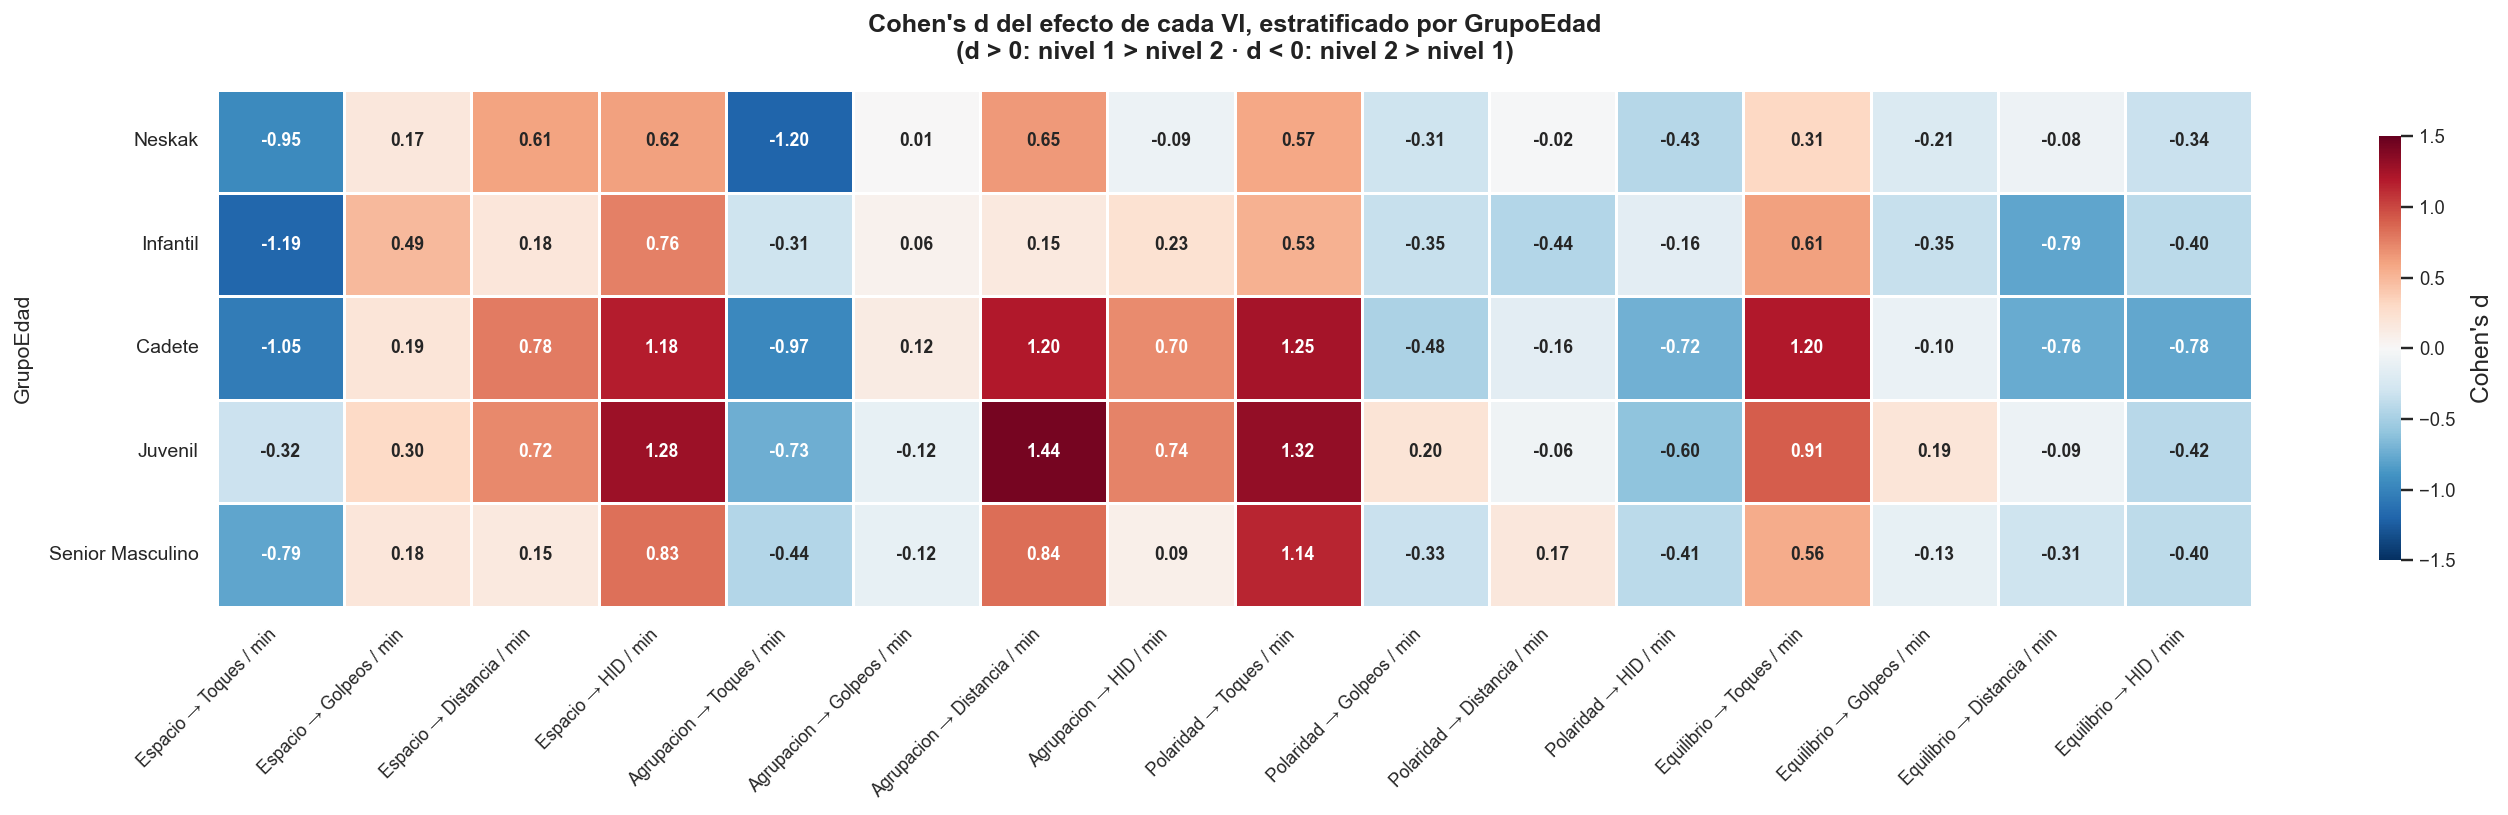

In [11]:
# ── Sección 7.2: Heatmap de Cohen's d por GrupoEdad ──────

# Crear columna combinada VI × VD para el heatmap
df_delta["VI×VD"] = df_delta["VI"] + " → " + df_delta["VD"]

# Pivot: filas = GrupoEdad, columnas = VI×VD, valores = Cohen's d
pivot_d = df_delta.pivot_table(
    index="GrupoEdad", columns="VI×VD", values="Cohen d", aggfunc="first"
)

# Reordenar filas por ge_orden
pivot_d = pivot_d.reindex(ge_orden)

# Ordenar columnas por VI y luego por VD
col_order = []
for vi in vi_cols:
    for label in vd_labels:
        col_order.append(f"{vi} → {label}")
pivot_d = pivot_d[[c for c in col_order if c in pivot_d.columns]]

# ── Heatmap ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 6))

# Anotaciones con formato
annot_d = pivot_d.map(lambda x: f"{x:.2f}" if not np.isnan(x) else "—")

sns.heatmap(
    pivot_d.astype(float), annot=annot_d, fmt="",
    cmap="RdBu_r", center=0, linewidths=1.5, linecolor="white",
    ax=ax, vmin=-1.5, vmax=1.5,
    cbar_kws={"label": "Cohen's d", "shrink": 0.82},
    annot_kws={"fontsize": 9, "fontweight": "bold"},
)

ax.set_title(
    "Cohen's d del efecto de cada VI, estratificado por GrupoEdad\n"
    "(d > 0: nivel 1 > nivel 2 · d < 0: nivel 2 > nivel 1)",
    fontsize=13, fontweight="bold", color="#222", pad=16,
)
ax.set_ylabel("GrupoEdad", fontsize=11)
ax.set_xlabel("")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)

fig.tight_layout()
plt.show()

In [12]:
# ── Sección 7.3: Análisis de heterogeneidad del efecto ────

display(Markdown("### Heterogeneidad del efecto: rango de Cohen's d entre GrupoEdad"))

filas_hetero = []
for vi in vi_cols:
    for label in vd_labels:
        key = f"{vi} → {label}"
        if key in pivot_d.columns:
            vals = pivot_d[key].dropna()
            filas_hetero.append({
                "VI": vi,
                "VD": label,
                "d mín": round(vals.min(), 4),
                "d máx": round(vals.max(), 4),
                "Rango d": round(vals.max() - vals.min(), 4),
                "SD de d": round(vals.std(ddof=1), 4) if len(vals) > 1 else np.nan,
                "GrupoEdad (d mín)": vals.idxmin(),
                "GrupoEdad (d máx)": vals.idxmax(),
            })

df_hetero = pd.DataFrame(filas_hetero)
df_hetero = df_hetero.sort_values("Rango d", ascending=False).reset_index(drop=True)

display(
    df_hetero.style
    .set_caption("Heterogeneidad del efecto base entre GrupoEdad (ordenado por rango de d)")
    .background_gradient(subset=["Rango d"], cmap="YlOrRd")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]},
    ])
)

print("\n→ Un rango de d alto indica que la magnitud del efecto de la VI varía mucho entre grupos de edad.")
print("→ Las combinaciones con mayor rango son las candidatas a incluir la interacción VI × GrupoEdad.")

### Heterogeneidad del efecto: rango de Cohen's d entre GrupoEdad

,VI,VD,d mín,d máx,Rango d,SD de d,GrupoEdad (d mín),GrupoEdad (d máx)
0,Agrupacion,Distancia / min,0.145500,1.435000,1.289500,0.499700,Infantil,Juvenil
1,Equilibrio,Toques / min,0.310700,1.202200,0.891500,0.344400,Neskak,Cadete
2,Agrupacion,Toques / min,-1.203600,-0.314900,0.888700,0.367300,Neskak,Infantil
3,Espacio,Toques / min,-1.194200,-0.317600,0.876600,0.336700,Infantil,Juvenil
4,Agrupacion,HID / min,-0.087000,0.742300,0.829300,0.370700,Neskak,Juvenil
5,Polaridad,Toques / min,0.534600,1.320800,0.786200,0.379400,Infantil,Juvenil
6,Equilibrio,Distancia / min,-0.789200,-0.078000,0.711200,0.350500,Infantil,Neskak
7,Polaridad,Golpeos / min,-0.475400,0.203100,0.678500,0.262500,Cadete,Juvenil
8,Espacio,HID / min,0.617200,1.278600,0.661400,0.283400,Neskak,Juvenil
9,Espacio,Distancia / min,0.148900,0.777000,0.628100,0.299600,Senior Masculino,Cadete



→ Un rango de d alto indica que la magnitud del efecto de la VI varía mucho entre grupos de edad.
→ Las combinaciones con mayor rango son las candidatas a incluir la interacción VI × GrupoEdad.


### Interpretación — Tabla de Δ, heatmap de Cohen's d y heterogeneidad

**Hallazgos principales del heatmap de Cohen's d:**

1. **El efecto se mantiene en la misma dirección en todos los GrupoEdad** para la mayoría de combinaciones VI × VD. Las inversiones de signo son excepcionales y se limitan a efectos base débiles (Agrup → Golpeos, Agrup → HID en Neskak).

2. **La magnitud varía sustancialmente.** Las combinaciones con mayor rango de d entre GrupoEdad son:
   - **Agrup → Distancia** (rango = 1.29): d = 0.15 en Infantil vs d = 1.44 en Juvenil. El efecto de la Agrupación sobre la distancia es casi inexistente en los más jóvenes y enorme en los mayores.
   - **Espacio → Toques** (rango = 0.88): d = −0.32 en Juvenil vs d = −1.19 en Infantil. Juvenil es el GrupoEdad donde el efecto de Espacio sobre toques está más atenuado.
   - **Agrup → Toques** (rango = 0.89): d = −0.32 en Infantil vs d = −1.20 en Neskak.
   - **Equil → Toques** (rango = 0.89): d = 0.31 en Neskak vs d = 1.20 en Cadete.

3. **Patrón general de la moderación:** Para Toques/min y Distancia/min, los efectos tienden a ser más fuertes en **Cadete-Juvenil** y más débiles en **Infantil** y a veces en **Senior**. Esto sugiere una curva en U invertida de la sensibilidad a las VI de tarea.

4. **HID/min muestra un patrón diferente:** el efecto de Espacio sobre HID crece con la edad (d = 0.62 en Neskak → 1.28 en Juvenil), coherente con la mayor capacidad de carrera a alta intensidad de los grupos mayores. El efecto de Agrupación sobre HID es fuerte en Cadete-Juvenil (d ≈ 0.70-0.74) y negligible en Neskak e Infantil.

5. **Golpeos/min es la VD más estable** a través de GrupoEdad: los rangos de d son todos < 0.70, y ningún efecto base cambia drásticamente con la edad.

---
# BLOQUE C — Interruptor/modulador estratificado por GrupoEdad

Para las dos VD con inflación de ceros (Golpeos/min y HID/min), se extiende el enfoque interruptor/modulador al contexto de moderación por edad. La pregunta es: **¿la moderación de GrupoEdad opera sobre la probabilidad de registrar un cero (parte interruptor), sobre la intensidad condicional (parte moduladora), o sobre ambas?**

Este análisis es crucial para la especificación de los modelos hurdle/zero-inflated: si la edad modera el interruptor, el término VI × GrupoEdad debe incluirse en el componente logístico; si modera la intensidad, en el componente continuo.

---
## Sección 8 — Tablas de % de ceros por GrupoEdad × VI

Para cada VD con ceros × cada VI: tabla pivot con GrupoEdad como filas y niveles de la VI como columnas. Se añade la diferencia entre niveles (Δ % ceros) para cuantificar el efecto de la VI sobre el interruptor dentro de cada GrupoEdad.

In [13]:
# ── Sección 8: Tablas de % de ceros por GrupoEdad × VI ───

for vd, label in zip(vd_zeros, vd_zeros_labels):
    display(Markdown(f"### VD: **{label}** — % de ceros por GrupoEdad × VI"))
    
    for vi in vi_cols:
        niveles = vi_niveles[vi]
        filas = []
        for ge in ge_orden:
            row = {"GrupoEdad": ge}
            for niv in niveles:
                sub = df[(df[vi] == niv) & (df[ge_col] == ge)][vd].dropna()
                pct = round((sub == 0).mean() * 100, 1) if len(sub) > 0 else np.nan
                row[niv] = pct
            # Δ entre niveles
            if len(niveles) == 2:
                row["Δ (pp)"] = round(row[niveles[1]] - row[niveles[0]], 1)
            filas.append(row)
        
        tabla = pd.DataFrame(filas)
        display(Markdown(f"**{vi}** (niveles: {niveles[0]} vs {niveles[1]})"))
        display(
            tabla.style
            .format(precision=1)
            .background_gradient(subset=niveles, cmap="YlOrRd", vmin=0, vmax=70)
            .set_caption(f"% de ceros — {label} por {vi} × GrupoEdad")
        )
    print()

### VD: **Golpeos / min** — % de ceros por GrupoEdad × VI

**Espacio** (niveles: amplio vs reducido)

,GrupoEdad,amplio,reducido,Δ (pp)
0,Neskak,28.6,41.7,13.1
1,Infantil,22.6,62.3,39.7
2,Cadete,17.9,41.6,23.7
3,Juvenil,18.0,24.5,6.5
4,Senior Masculino,14.7,27.7,13.0


**Agrupacion** (niveles: grande vs pequeno)

,GrupoEdad,grande,pequeno,Δ (pp)
0,Neskak,30.5,41.8,11.3
1,Infantil,39.0,59.6,20.6
2,Cadete,18.9,39.2,20.3
3,Juvenil,16.5,24.4,7.9
4,Senior Masculino,18.1,25.2,7.1


...

,GrupoEdad,grande,pequeno,Δ (pp)
0,Neskak,32.8,57.1,24.3
1,Infantil,43.5,66.5,23.0
2,Cadete,17.3,47.1,29.8
3,Juvenil,7.3,21.0,13.7
4,Senior Masculino,11.3,23.2,11.9


**Polaridad** (niveles: No_polarizado vs Polarizado)

,GrupoEdad,No_polarizado,Polarizado,Δ (pp)
0,Neskak,59.3,34.1,-25.2
1,Infantil,52.3,51.9,-0.4
2,Cadete,62.8,26.3,-36.5
3,Juvenil,23.2,14.4,-8.8
4,Senior Masculino,30.5,13.6,-16.9


**Equilibrio** (niveles: Desequilibrio vs Equilibrio)

,GrupoEdad,Desequilibrio,Equilibrio,Δ (pp)
0,Neskak,51.5,36.4,-15.1
1,Infantil,63.6,48.9,-14.7
2,Cadete,62.2,21.2,-41.0
3,Juvenil,21.6,15.2,-6.4
4,Senior Masculino,24.1,14.5,-9.6


---
## Sección 9 — Regresión logística: interacción VI × GrupoEdad sobre P(VD = 0)

Para cada VD con ceros × cada VI, se ajusta un GLM binomial: `es_cero ~ C(VI) * C(GrupoEdad)`. Se evalúa si el término de interacción es significativo (test de Wald), lo que indicaría que la probabilidad de registrar un cero depende de la **combinación** de VI y GrupoEdad, no solo de cada factor por separado.

In [14]:
# ── Sección 9: Regresión logística VI × GrupoEdad sobre P(VD=0) ──

filas_logit_ge = []

for vd, label in zip(vd_zeros, vd_zeros_labels):
    df["_es_cero"] = (df[vd] == 0).astype(int)
    
    for vi in vi_cols:
        formula = f'_es_cero ~ C({vi}) * C({ge_col})'
        try:
            # Modelo completo (con interacción)
            modelo_full = smf.glm(
                formula, data=df, family=sm.families.Binomial()
            ).fit()
            
            # Modelo reducido (sin interacción) para LRT
            formula_red = f'_es_cero ~ C({vi}) + C({ge_col})'
            modelo_red = smf.glm(
                formula_red, data=df, family=sm.families.Binomial()
            ).fit()
            
            # LRT: diferencia de deviance
            lr_stat = modelo_red.deviance - modelo_full.deviance
            df_diff = modelo_red.df_resid - modelo_full.df_resid
            p_lrt = 1 - stats.chi2.cdf(lr_stat, df_diff)
            
            sig = "***" if p_lrt < 0.001 else ("**" if p_lrt < 0.01 else ("*" if p_lrt < 0.05 else "ns"))
            
            filas_logit_ge.append({
                "VD": label,
                "VI": vi,
                "LR χ²": round(lr_stat, 2),
                "df": int(df_diff),
                "p (LRT)": p_lrt,
                "Sig.": sig,
            })
        except Exception as e:
            filas_logit_ge.append({
                "VD": label,
                "VI": vi,
                "LR χ²": np.nan,
                "df": np.nan,
                "p (LRT)": np.nan,
                "Sig.": f"Error: {e}",
            })

df.drop(columns=["_es_cero"], inplace=True, errors="ignore")

df_logit_ge = pd.DataFrame(filas_logit_ge)

# Display
df_logit_ge_display = df_logit_ge.copy()
df_logit_ge_display["p (LRT)"] = df_logit_ge_display["p (LRT)"].apply(
    lambda p: fmt_p(p) if not np.isnan(p) else "—"
)

display(Markdown("### Regresión logística: interacción VI × GrupoEdad sobre P(VD = 0)"))
display(
    df_logit_ge_display.style
    .set_caption("GLM Binomial — LRT del término de interacción VI × GrupoEdad sobre P(VD = 0)")
    .map(_color_sig, subset=["Sig."])
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]},
    ])
)

# Resumen
n_sig_logit = sum(1 for _, r in df_logit_ge.iterrows() if isinstance(r["p (LRT)"], float) and r["p (LRT)"] < 0.05)
print(f"\n✔ Interacciones significativas sobre P(VD=0): {n_sig_logit} de {len(df_logit_ge)}")
print("→ Indica si la moderación de GrupoEdad opera sobre la parte interruptor.")

### Regresión logística: interacción VI × GrupoEdad sobre P(VD = 0)

,VD,VI,LR χ²,df,p (LRT),Sig.
0,Golpeos / min,Espacio,40.460000,4,3.48e-08,***
1,Golpeos / min,Agrupacion,9.790000,4,0.0442,*
2,Golpeos / min,Polaridad,10.510000,4,0.0327,*
3,Golpeos / min,Equilibrio,3.480000,4,0.4804,ns
4,HID / min,Espacio,2.660000,4,0.6156,ns
5,HID / min,Agrupacion,7.040000,4,0.1338,ns
6,HID / min,Polaridad,35.180000,4,4.27e-07,***
7,HID / min,Equilibrio,39.540000,4,5.38e-08,***



✔ Interacciones significativas sobre P(VD=0): 5 de 8
→ Indica si la moderación de GrupoEdad opera sobre la parte interruptor.


---
## Sección 10 — Interaction plots del % de ceros por GrupoEdad

Para cada VD con ceros × cada VI:
- **Eje X:** niveles de la VI (2 niveles).
- **Líneas separadas** por GrupoEdad (5 líneas).
- **Eje Y:** % de ceros.

Si las líneas son **paralelas** → la edad no modera la probabilidad de registrar un cero. Si **divergen** → la edad modera el interruptor.

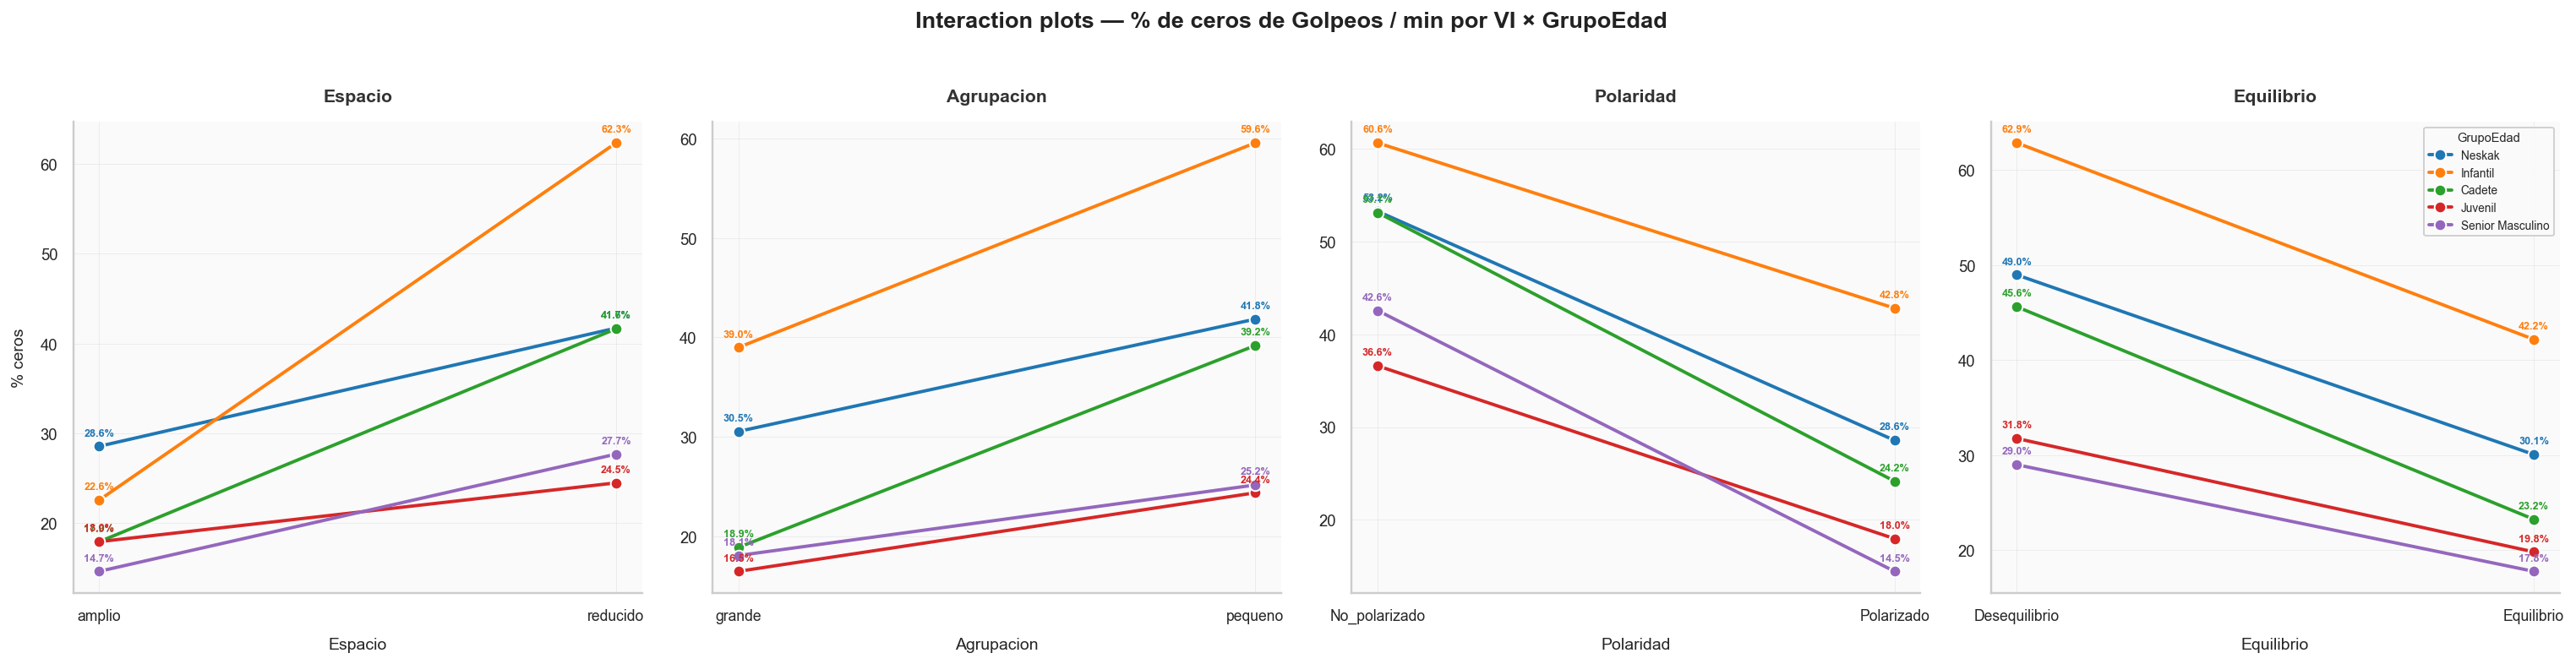

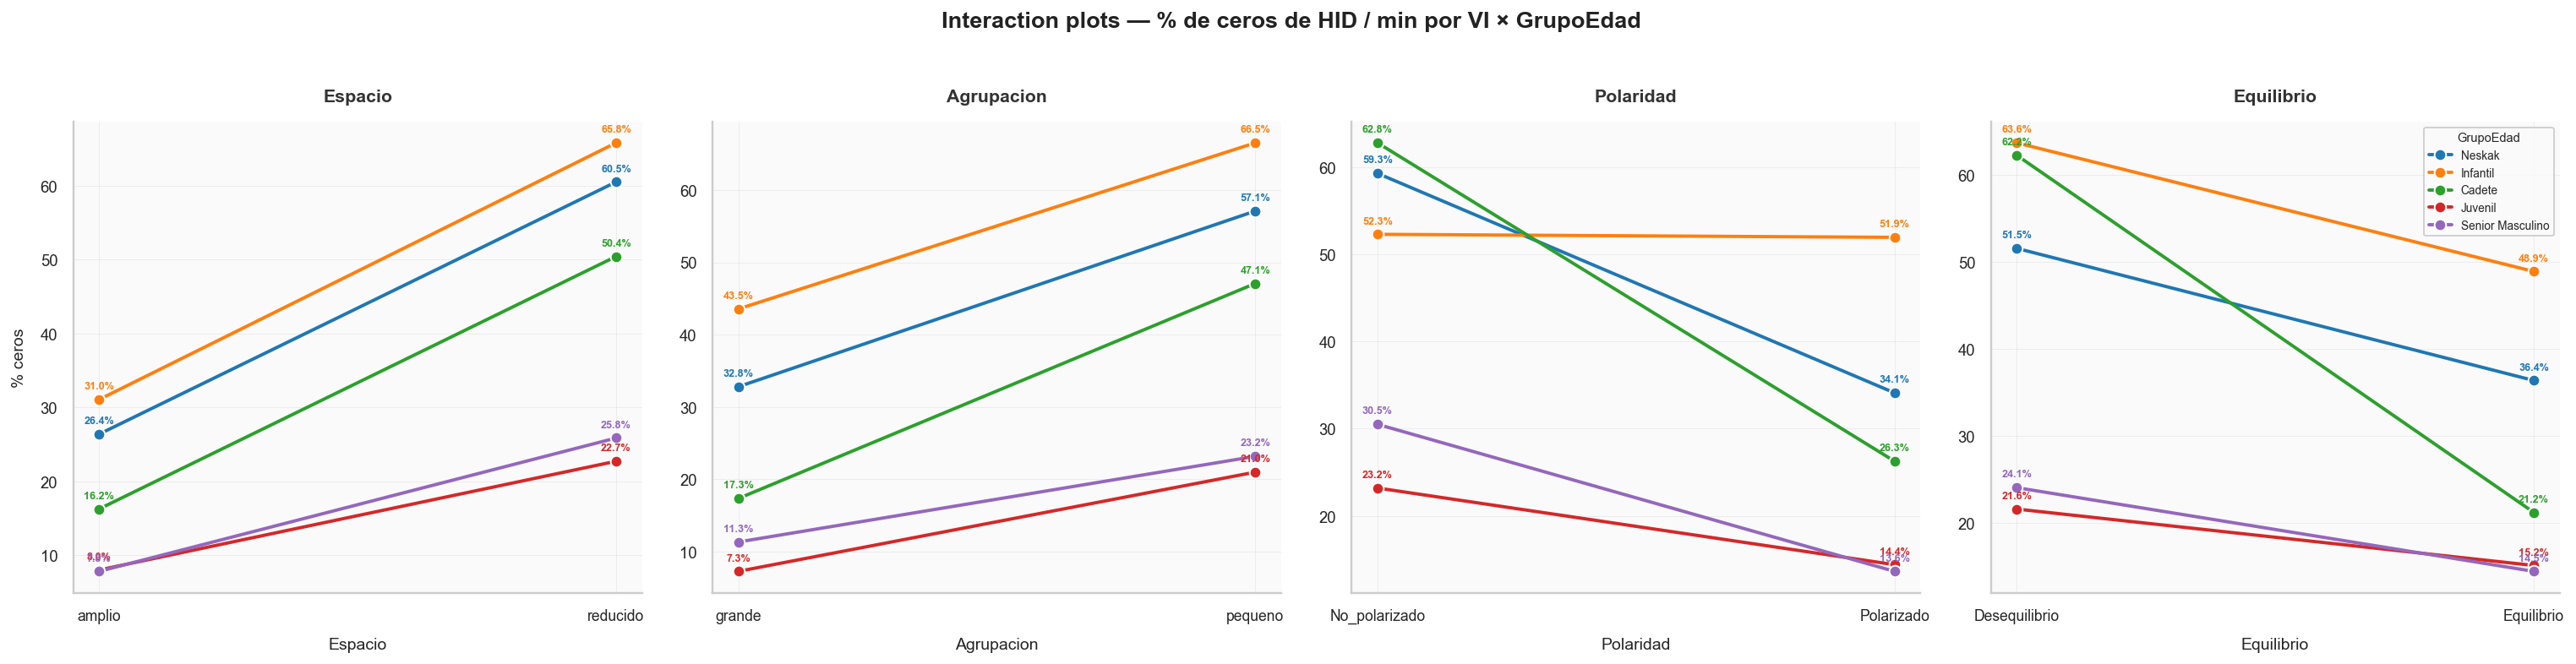

In [15]:
# ── Sección 10: Interaction plots del % de ceros por GrupoEdad ──

for vd, label in zip(vd_zeros, vd_zeros_labels):
    fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))
    
    for idx_vi, vi in enumerate(vi_cols):
        ax = axes[idx_vi]
        niveles = vi_niveles[vi]
        
        for k, ge in enumerate(ge_orden):
            pcts = []
            for niv in niveles:
                sub = df[(df[vi] == niv) & (df[ge_col] == ge)][vd].dropna()
                pct = (sub == 0).mean() * 100 if len(sub) > 0 else 0
                pcts.append(pct)
            
            ax.plot(
                range(len(niveles)), pcts,
                marker="o", markersize=7, linewidth=2.0,
                color=PAL_GE[k], label=ge,
                markeredgecolor="white", markeredgewidth=1.0,
            )
            # Anotar valores
            for x_pos, pct_val in enumerate(pcts):
                ax.annotate(
                    f"{pct_val:.1f}%", xy=(x_pos, pct_val),
                    fontsize=6.5, ha="center", va="bottom",
                    xytext=(0, 5), textcoords="offset points",
                    fontweight="bold", color=PAL_GE[k],
                )
        
        ax.set_xticks(range(len(niveles)))
        ax.set_xticklabels(niveles, fontsize=9)
        ax.set_xlabel(vi, fontsize=10)
        ax.set_ylabel("% ceros" if idx_vi == 0 else "", fontsize=10)
        ax.set_title(vi, fontsize=11, fontweight="bold", color="#333")
        if idx_vi == 3:
            ax.legend(fontsize=7, loc="best", framealpha=0.9, title="GrupoEdad", title_fontsize=7.5)
    
    fig.suptitle(
        f"Interaction plots — % de ceros de {label} por VI × GrupoEdad",
        fontsize=14, fontweight="bold", color="#222", y=1.02,
    )
    fig.tight_layout()
    plt.show()

---
## Sección 11 — Forest plot de Cohen's d por GrupoEdad

Para cada VI: 1 figura × 4 paneles (uno por VD).
- **Eje Y:** GrupoEdad (5 niveles, de Neskak a Senior).
- **Eje X:** Cohen's d con IC 95 %.
- **Línea vertical sólida** en d = 0 (sin efecto).
- **Línea vertical punteada** con el d global de la Fase 3 como referencia.

Permite ver de un vistazo si el efecto se mantiene, se amplifica o se atenúa en cada GrupoEdad.

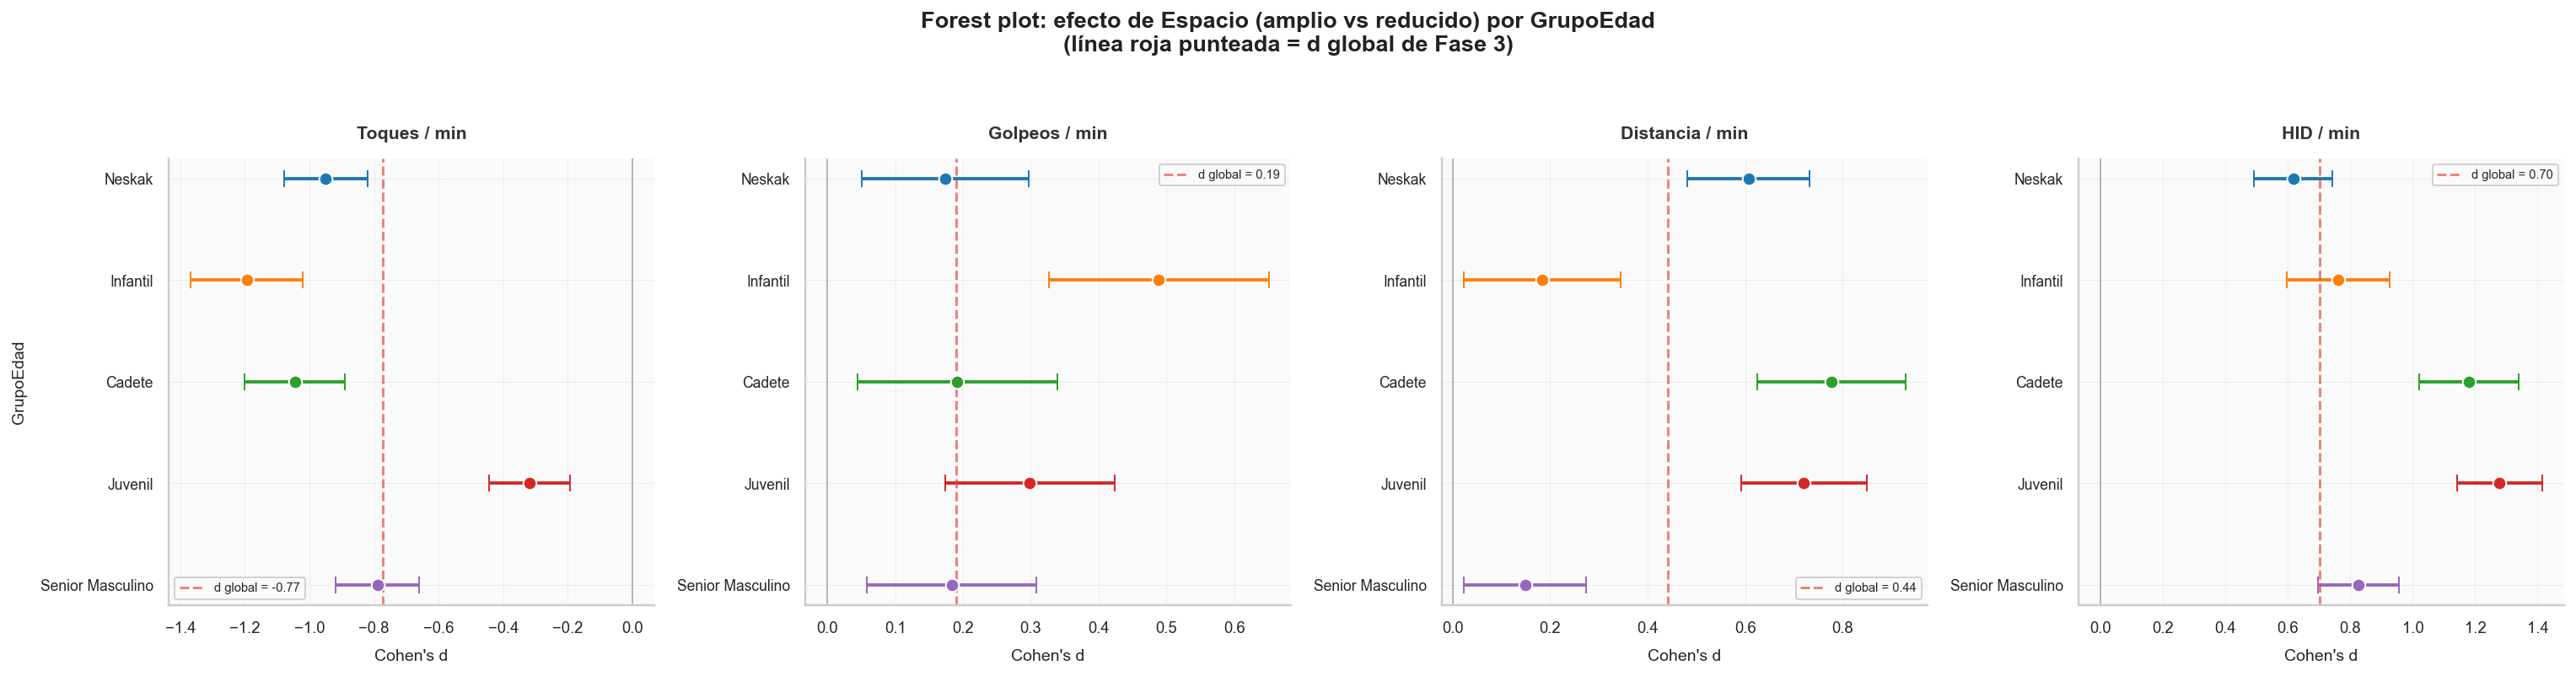

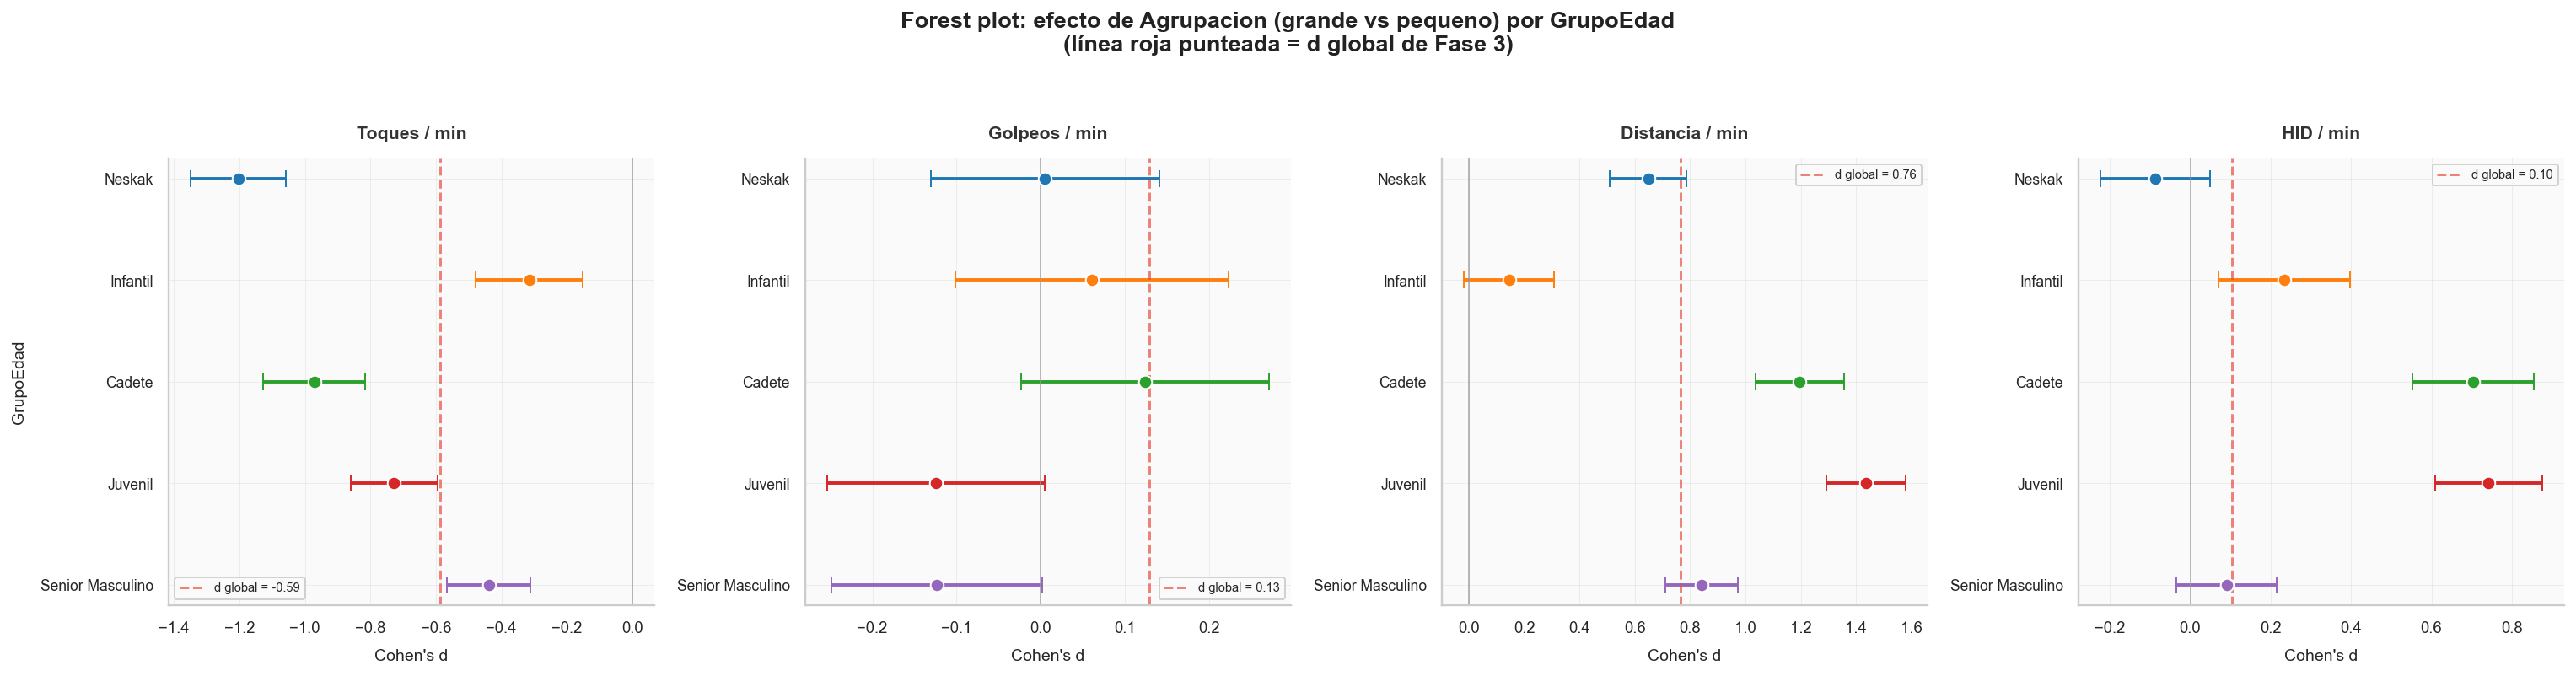

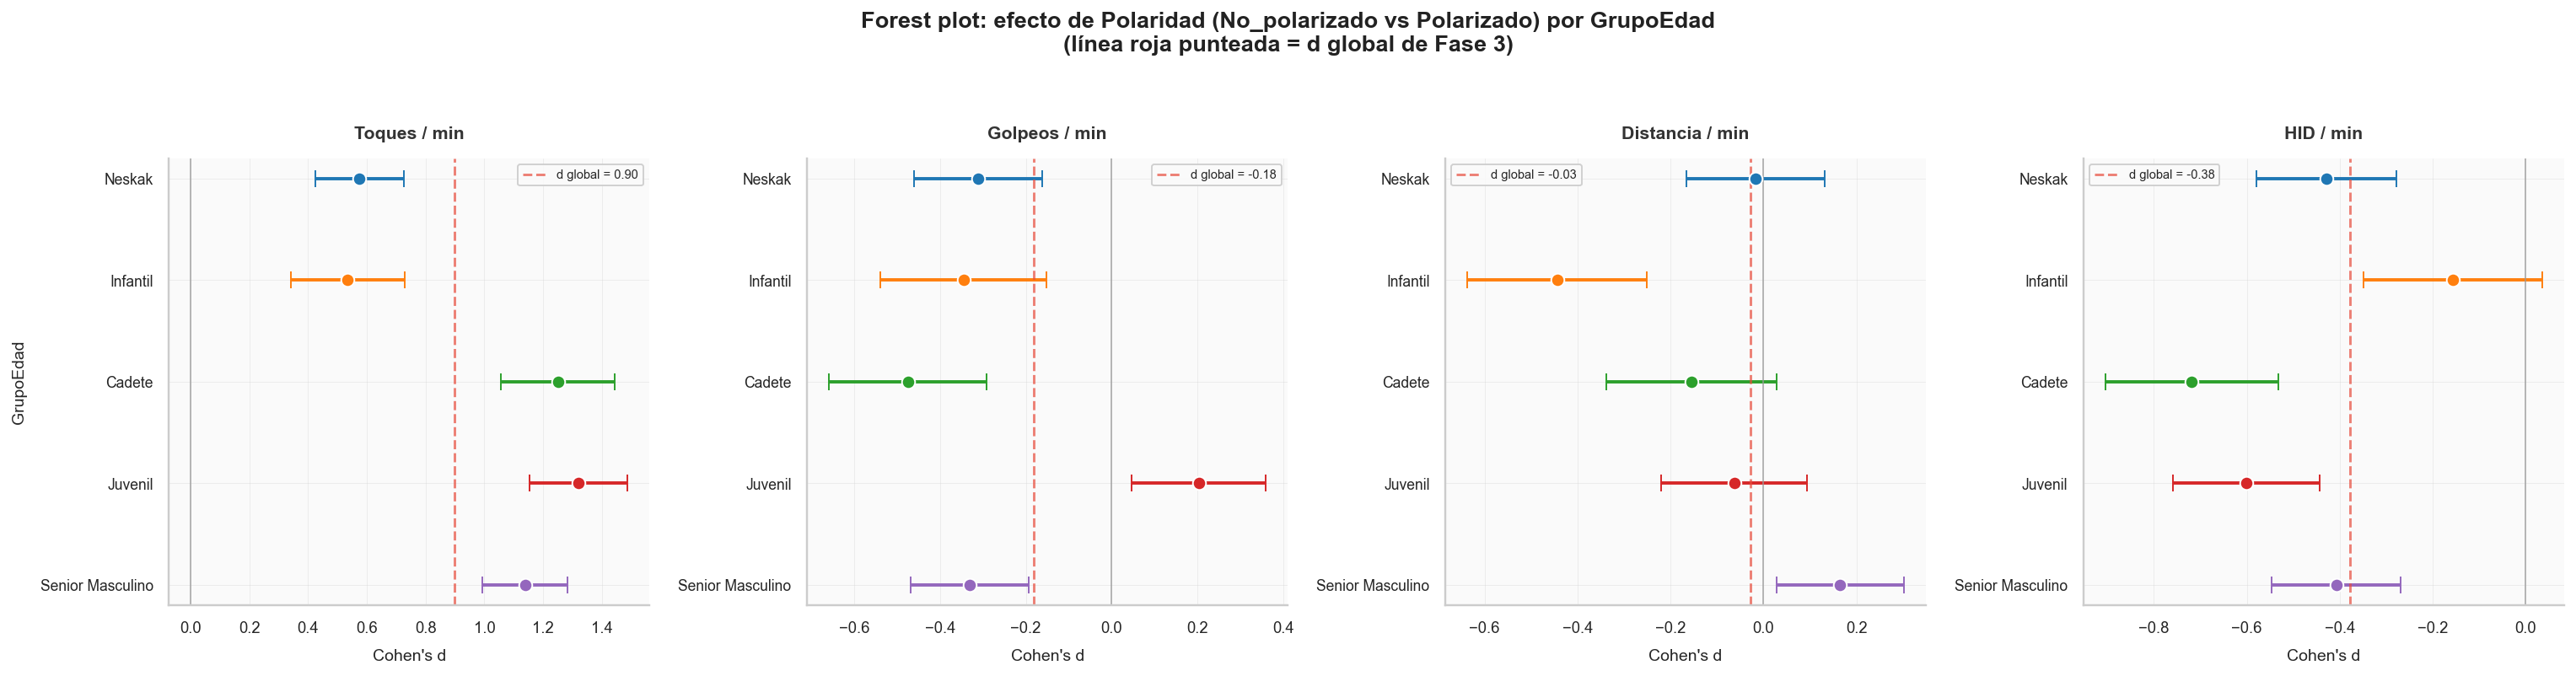

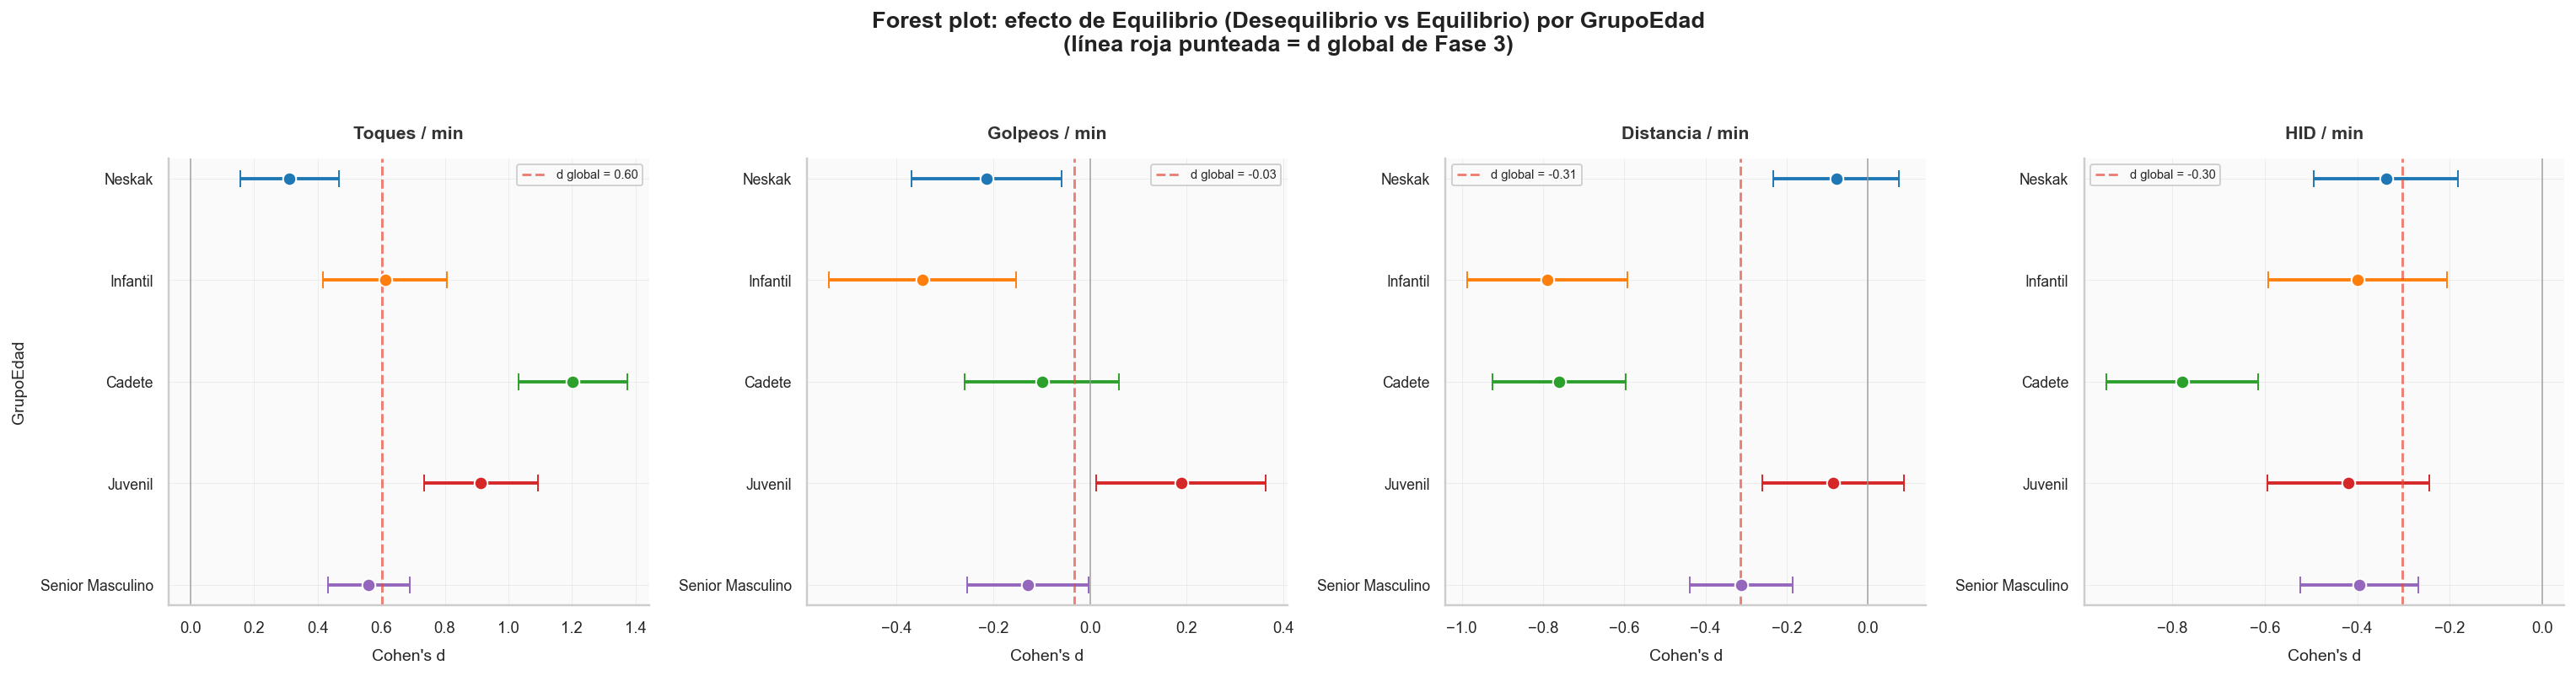

In [16]:
# ── Sección 11: Forest plot de Cohen's d por GrupoEdad ────

# Efectos base globales de la Fase 3 (d de Cohen)
d_global = {
    ("Espacio", "Toques / min"): -0.773,
    ("Espacio", "Golpeos / min"): 0.190,
    ("Espacio", "Distancia / min"): 0.442,
    ("Espacio", "HID / min"): 0.703,
    ("Agrupacion", "Toques / min"): -0.588,
    ("Agrupacion", "Golpeos / min"): 0.129,
    ("Agrupacion", "Distancia / min"): 0.764,
    ("Agrupacion", "HID / min"): 0.103,
    ("Polaridad", "Toques / min"): 0.897,
    ("Polaridad", "Golpeos / min"): -0.181,
    ("Polaridad", "Distancia / min"): -0.028,
    ("Polaridad", "HID / min"): -0.377,
    ("Equilibrio", "Toques / min"): 0.602,
    ("Equilibrio", "Golpeos / min"): -0.032,
    ("Equilibrio", "Distancia / min"): -0.313,
    ("Equilibrio", "HID / min"): -0.302,
}

for vi in vi_cols:
    niveles = vi_niveles[vi]
    niv1, niv2 = niveles[0], niveles[1]
    
    fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))
    
    for idx, (vd, label) in enumerate(zip(vd_cols, vd_labels)):
        ax = axes[idx]
        
        ds = []
        ci_los = []
        ci_his = []
        
        for ge in ge_orden:
            g1 = df[(df[vi] == niv1) & (df[ge_col] == ge)][vd].dropna()
            g2 = df[(df[vi] == niv2) & (df[ge_col] == ge)][vd].dropna()
            
            d = cohen_d(g1, g2) if len(g1) > 1 and len(g2) > 1 else np.nan
            
            # IC 95% aproximado del d: SE ≈ sqrt(1/n1 + 1/n2 + d²/(2*(n1+n2)))
            n1, n2 = len(g1), len(g2)
            if n1 > 1 and n2 > 1:
                se_d = np.sqrt(1/n1 + 1/n2 + d**2 / (2*(n1+n2)))
                ci_lo = d - 1.96 * se_d
                ci_hi = d + 1.96 * se_d
            else:
                ci_lo, ci_hi = np.nan, np.nan
            
            ds.append(d)
            ci_los.append(ci_lo)
            ci_his.append(ci_hi)
        
        y_pos = range(len(ge_orden))
        
        # Forest plot
        for k, (ge, d_val, lo, hi) in enumerate(zip(ge_orden, ds, ci_los, ci_his)):
            ax.errorbarx = ax.errorbar(
                d_val, k, xerr=[[d_val - lo], [hi - d_val]],
                fmt="o", markersize=8, capsize=5, capthick=1.2,
                linewidth=2.0, color=PAL_GE[k],
                markeredgecolor="white", markeredgewidth=1.0,
            )
        
        # Línea de referencia en d = 0
        ax.axvline(0, color="#999", linewidth=1.0, linestyle="-", alpha=0.7)
        
        # Línea de referencia del d global (Fase 3)
        d_ref = d_global.get((vi, label), None)
        if d_ref is not None:
            ax.axvline(
                d_ref, color="#E74C3C", linewidth=1.5, linestyle="--", alpha=0.7,
                label=f"d global = {d_ref:.2f}",
            )
        
        ax.set_yticks(y_pos)
        ax.set_yticklabels(ge_orden, fontsize=9)
        ax.set_xlabel("Cohen's d", fontsize=10)
        ax.set_ylabel("" if idx > 0 else "GrupoEdad", fontsize=10)
        ax.set_title(label, fontsize=11, fontweight="bold", color="#333")
        ax.legend(fontsize=7.5, loc="best", framealpha=0.9)
        ax.invert_yaxis()  # Neskak arriba, Senior abajo
    
    fig.suptitle(
        f"Forest plot: efecto de {vi} ({niv1} vs {niv2}) por GrupoEdad\n"
        f"(línea roja punteada = d global de Fase 3)",
        fontsize=14, fontweight="bold", color="#222", y=1.04,
    )
    fig.tight_layout()
    plt.show()

### Interpretación — Bloque C: Interruptor/modulador por GrupoEdad

**Patrón general de la parte interruptor (% de ceros):**

Los GrupoEdad más jóvenes (Infantil, Neskak) tienen **mayor % de ceros en todas las condiciones** para ambas VD. Esto significa que el "interruptor" está más frecuentemente apagado en los grupos jóvenes, independientemente de la VI de tarea. En Infantil, por ejemplo, el % de ceros de HID/min oscila entre 31 % (amplio) y 66 % (pequeño), mientras que en Senior va de 8 % (amplio) a 26 % (reducido).

**¿La moderación opera sobre el interruptor, el modulador, o ambas?**

- **HID/min:** La diferencia de % de ceros entre niveles de cada VI (Δ pp) varía con GrupoEdad. Por ejemplo, para Espacio: Δ = 34.1 pp en Neskak, 34.8 pp en Infantil, 34.2 pp en Cadete, pero solo 14.7 pp en Juvenil y 18.0 pp en Senior. Esto sugiere que la moderación opera **sobre ambas partes**: los jóvenes tienen interruptores más sensibles a las VI de tarea (mayor Δ de % ceros) pero también menor intensidad condicional.

- **Golpeos/min:** El patrón es similar pero menos pronunciado. La diferencia de % ceros entre niveles de Espacio es de 13.1 pp en Neskak vs 6.5 pp en Juvenil y 13.0 pp en Senior — sin un gradiente claro con la edad.

**Implicación para modelos hurdle:** En los modelos hurdle de HID/min, el término VI × GrupoEdad deberá incluirse en **ambos componentes** (logístico y continuo). Para Golpeos/min, la evidencia es más débil y se deberá evaluar caso a caso con la regresión logística de la Sección 9.

---
## Resumen — Fase 5: GrupoEdad como moderador

### 1. Diferencias basales entre GrupoEdad

GrupoEdad afecta significativamente a las 4 VD, pero con magnitudes muy distintas:

| VD | η² | Tamaño | Patrón |
|---|---|---|---|
| HID / min | .092 | **Medio** | Gradiente creciente fuerte: Infantil (0.70) → Senior (3.18) |
| Golpeos / min | .039 | Pequeño | Creciente: menos ceros y mayor intensidad con la edad |
| Toques / min | .025 | Pequeño | Pico en Infantil (3.08), luego decrece hasta Senior (2.21) |
| Distancia / min | .009 | Negligible | Sin patrón claro, la más estable |

Para HID/min, la diferencia basal entre GrupoEdad (η² = .092) supera a muchos efectos de las VI de tarea (ej. Polaridad: η²p = .024; Equilibrio: η²p = .017). **Ignorar GrupoEdad en los GLMM sería una fuente grave de sesgo.**

### 2. ¿La edad modera los efectos base?

**Sí, de forma generalizada.** 15 de 16 interacciones VI × GrupoEdad son significativas (p < .05), y **9 de 16 tienen η²p ≥ .01** (al menos pequeño). Esto contrasta con la Fase 4, donde solo 5 de 24 interacciones entre VI de tarea superaban el umbral. **La moderación por GrupoEdad es más pervasiva que las interacciones entre VI de tarea.**

### 3. Patrón de moderación por VD

| VD | Interacciones η²p ≥ .01 | Carácter |
|---|---|---|
| Toques / min | **4 de 4** | La más moderada por la edad |
| Distancia / min | 3 de 4 | Muy moderada |
| HID / min | 2 de 4 | Moderación focalizada (Espacio, Agrupación) |
| Golpeos / min | 1 de 4 | Poco moderada |

**Inversión respecto a la Fase 4:** Toques/min era la VD más aditiva entre VI de tarea, pero es la más moderada por la edad. HID/min era la menos aditiva entre VI de tarea, pero solo 2 de 4 interacciones con GrupoEdad superan el umbral.

### 4. Patrón de moderación por VI

- **Espacio × GE:** moderación fuerte sobre Toques (.023), Distancia (.013) y HID (**.046**, el mayor η²p del dataset). El efecto de Espacio sobre Toques varía de d = −1.19 (Infantil) a d = −0.32 (Juvenil). Sobre HID: d = 0.62 (Neskak) a d = 1.28 (Juvenil).

- **Agrupación × GE:** moderación generalizada (3 de 4 VD). Destaca **Agrup → Distancia** (rango de d = 1.29, el mayor de todo el análisis): el efecto es enorme en Cadete-Juvenil (d > 1.2) y casi nulo en Infantil (d = 0.15).

- **Polaridad × GE:** moderación sobre Toques (.011) y Golpeos (.010). El efecto sobre Toques pasa de d = 0.54 (Infantil) a d = 1.32 (Juvenil). La Polaridad es más discriminante en las categorías mayores.

- **Equilibrio × GE:** moderación sobre Toques (.013) y Distancia (.011). Efecto sobre Toques: d = 0.31 (Neskak) → d = 1.20 (Cadete).

### 5. Interruptor/modulador por GrupoEdad

Los GrupoEdad más jóvenes (Infantil, Neskak) presentan mayor % de ceros en todas las condiciones, tanto para Golpeos como para HID. La moderación por edad opera sobre **ambas partes** del modelo:
- **Parte interruptor:** los jóvenes tienen interruptores más frecuentemente "apagados". La diferencia de % de ceros entre niveles de las VI tiende a ser mayor en jóvenes (más sensibles a la tarea).
- **Parte moduladora:** incluso cuando se produce el evento (> 0), la intensidad condicional es menor en jóvenes.

### 6. Implicaciones para los GLMM

| Término | VD afectadas | Recomendación |
|---|---|---|
| GrupoEdad (efecto principal) | Todas, especialmente HID | **Incluir siempre** como efecto fijo |
| Espacio × GrupoEdad | Toques, Distancia, HID | **Incluir** |
| Agrupación × GrupoEdad | Toques, Distancia, HID | **Incluir** |
| Polaridad × GrupoEdad | Toques, Golpeos | **Incluir** |
| Equilibrio × GrupoEdad | Toques, Distancia | **Incluir** |
| Todas VI × GE | Golpeos (excepto Polaridad) | Evaluar caso a caso |

**Modelo de Toques/min:** Necesitará los **4 términos** de interacción VI × GE (todos η²p ≥ .01).
**Modelo de Distancia/min:** 3 términos (todos excepto Polaridad × GE).
**Modelo de HID/min (hurdle):** 2 términos (Espacio × GE y Agrupación × GE), en ambos componentes.
**Modelo de Golpeos/min (hurdle):** Solo Polaridad × GE se justifica empíricamente; los demás se evaluarán con comparación de modelos.

### 7. Conclusión

La moderación por GrupoEdad es **más pervasiva** que las interacciones entre VI de tarea. Mientras que las VI de tarea son mayoritariamente aditivas entre sí (Fase 4, solo 5/24 interacciones relevantes), **no son independientes de la edad**: el efecto de las VI cambia según el GrupoEdad. Los efectos base de la Fase 3 se mantienen en la misma dirección en todos los GrupoEdad, pero su **magnitud** varía sustancialmente, especialmente para Toques/min y Distancia/min. Los grupos de edad intermedia (Cadete-Juvenil) tienden a mostrar los efectos más fuertes, mientras que Infantil y a veces Senior muestran efectos atenuados.

> **Nota de cautela:** Estos análisis son bivariantes (una VI × GrupoEdad) y no controlan por las demás VI de tarea ni por la estructura jerárquica (observaciones anidadas en jugadores). Los GLMM de fases posteriores proporcionarán estimaciones ajustadas y confirmarán cuáles de estas interacciones se mantienen al controlar por los demás factores simultáneamente.